## Settings and Utilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
from scipy.signal import hilbert

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 18
})

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Shared utility functions

In [7]:
# ------------------------------------------------------------
# Shared helper functions
# Used across the RK4, IMS, and other sections of this notebook,
# consolidated here to avoid re-defining identical logic in each cell.
# ------------------------------------------------------------

def make_1d_signal(x, var_name='unknown'):
    """Flatten a loaded .mat variable into a 1D float array.
    Input : x (array-like from a .mat file), var_name (for error messages)
    Output: 1D float ndarray
    """
    x = np.asarray(x)
    x = np.squeeze(x)
    if x.ndim != 1:
        raise ValueError(f'{var_name}: unexpected ndim={x.ndim}, shape={x.shape}')
    return x.astype(float)


def split_into_sets(x, n_set, n_per_set, var_name='unknown'):
    """Reshape a long 1D signal into (n_set, n_per_set).
    Input : x (1D array), n_set, n_per_set, var_name (for error messages)
    Output: 2D ndarray of shape (n_set, n_per_set)
    """
    expected_len = n_set * n_per_set
    if len(x) != expected_len:
        raise ValueError(f'{var_name}: length={len(x)}, expected={expected_len}')
    return x.reshape(n_set, n_per_set)


def single_sided_fft(x, fs):
    """Single-sided raw FFT amplitude spectrum.
    Input : x (1D signal), fs (sampling frequency)
    Output: (f, A) -- frequency axis [Hz] and amplitude spectrum
    """
    x = np.asarray(x).flatten()
    x = x - np.mean(x)
    N = len(x)
    f = np.fft.rfftfreq(N, d=1 / fs)
    A = np.abs(np.fft.rfft(x)) * 2.0 / N
    return f, A


def envelope_spectrum(x, fs):
    """Single-sided envelope (Hilbert) FFT amplitude spectrum.
    Input : x (1D signal), fs (sampling frequency)
    Output: (f, A) -- frequency axis [Hz] and envelope amplitude spectrum
    """
    x = np.asarray(x).flatten()
    x = x - np.mean(x)
    env = np.abs(hilbert(x))
    env = env - np.mean(env)
    return single_sided_fft(env, fs)


def find_peak_near(f, A, target, half_width):
    """Find the peak amplitude and its frequency within +/- half_width of target.
    Input : f, A (spectrum from single_sided_fft/envelope_spectrum),
            target (center frequency [Hz]), half_width (search window [Hz])
    Output: (amp, freq) -- peak amplitude and its exact frequency;
            (nan, nan) if no bin falls in the search window
    """
    idx = np.where((f >= target - half_width) & (f <= target + half_width))[0]
    if len(idx) == 0:
        return np.nan, np.nan
    i_local = idx[np.argmax(A[idx])]
    return A[i_local], f[i_local]


def mean_spectrum_across_sets(xset, fs, spectrum_func=single_sided_fft):
    """Average a spectrum (raw or envelope) across all sets/cycles.
    Input : xset (n_sets, n_per_set), fs, spectrum_func (single_sided_fft or envelope_spectrum)
    Output: (f, mean_A) -- common frequency axis and averaged amplitude spectrum
    """
    specs = [spectrum_func(xset[i, :], fs)[1] for i in range(xset.shape[0])]
    f = spectrum_func(xset[0, :], fs)[0]
    return f, np.mean(specs, axis=0)


def plot_data(x, y, legend_labels, ylabel, xlabel, title, figure_num,
              plot_type=1, xlim=None, marker='-'):
    """Plot one or more curves (y columns) against a common x-axis.
    Input : x, y (y can be 2D with one column per curve), legend_labels,
            axis labels, title, figure_num, plot_type (2 = log-log), xlim, marker
    Output: None (draws the figure)
    """
    plt.figure(figure_num)
    for idx in range(y.shape[1]):
        if plot_type == 2:
            plt.loglog(x, y[:, idx], marker, label=legend_labels[idx])
        else:
            plt.plot(x, y[:, idx], marker, label=legend_labels[idx])
    plt.grid(True)
    plt.legend(legend_labels)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.title(title, fontweight='bold')
    if xlim:
        plt.xlim(xlim)


## Statistics-based method

### virtual time series data

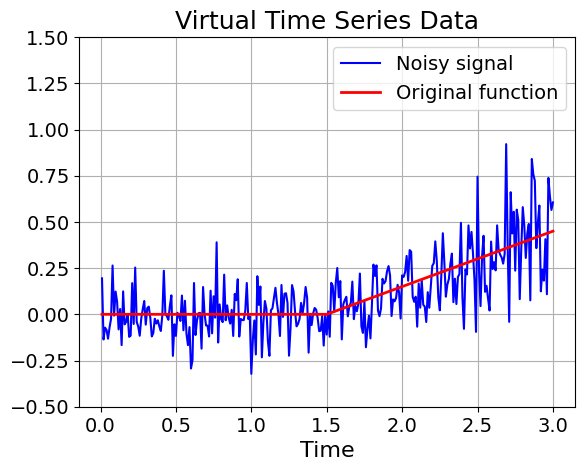

In [ ]:
# Create virtual time series data
t = np.arange(0.01, 3.00 + 0.01, 0.01)
N = len(t)
N2 = round(N / 2)
N1 = N - N2
td = t[N2 - 1]

e = 0.1
er = 1.5
r = 0.3

u = np.heaviside(t - td, 0.5)

# Original function without noise
x0 = r * (t - td) * u

# Noisy signal
xf = (
    e * np.random.randn(N)
    + e * er * np.random.randn(N) * (t - td) * u
    + x0
)

plt.plot(t, xf, 'b', label='Noisy signal')
plt.plot(t, x0, 'r', linewidth=2, label='Original function')
plt.ylim([-0.5, 1.5])
plt.xlabel('Time')
plt.grid(True)
plt.title('Virtual Time Series Data')
plt.legend()
plt.show()

savemat('/content/drive/MyDrive/PHM SUNYK/Datasets/xf_anomaly.mat', {'xf': xf, 't': t})


### T-test

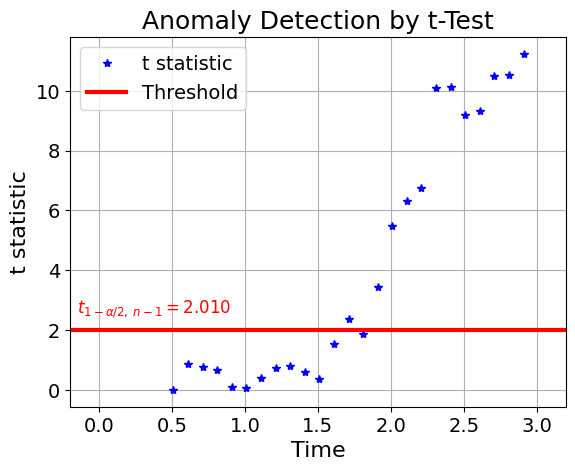

In [ ]:
# t-test based anomaly detection (mean change detection)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as tdist

rawData = loadmat('/content/drive/MyDrive/PHM SUNYK/Datasets/xf_anomaly.mat')
xf = rawData['xf'].flatten()
t = rawData['t'].flatten()

# example signal assumed already defined: xf

al = 0.05
n = 50
N = len(xf)

mu0 = np.mean(xf[:n])
tcrit = tdist.ppf(1 - al/2, n - 1)

Tval = np.full(N, np.nan)

for i in range(n, N, 10):
    xw = xf[i-n:i]
    mk = np.mean(xw)
    sk = np.std(xw, ddof=1)

    if sk > 0:
        Tval[i] = abs((mk - mu0) / (sk / np.sqrt(n)))
    else:
        Tval[i] = 0

plt.plot(t[n:N:10], Tval[n:N:10], 'b*', label='t statistic')
plt.axhline(tcrit, color='r', linewidth=3, label='Threshold')

# threshold text
ymax = np.nanmax(Tval[n:N:10])
offset = 0.05 * ymax

xmin = -0.2
plt.text(
    xmin + 0.05, tcrit + offset,
    rf'$t_{{1-\alpha/2,\;n-1}} = {tcrit:.3f}$',
    color='r', fontsize=12
)

plt.legend()
plt.grid(True)
plt.xlabel('Time')
plt.ylabel('t statistic')
plt.title('Anomaly Detection by t-Test')
plt.xlim([-0.2, 3.2])
plt.show()

### chi2 test

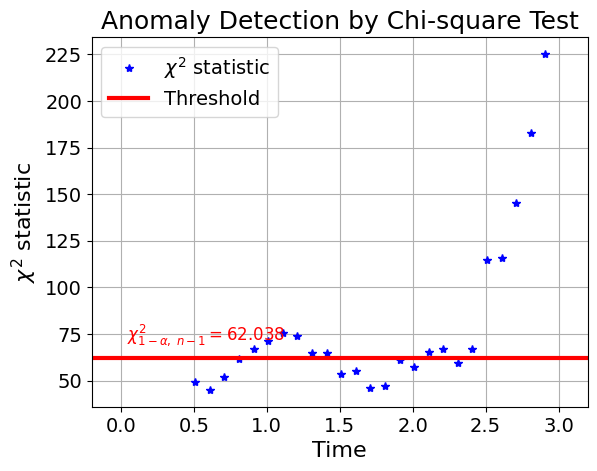

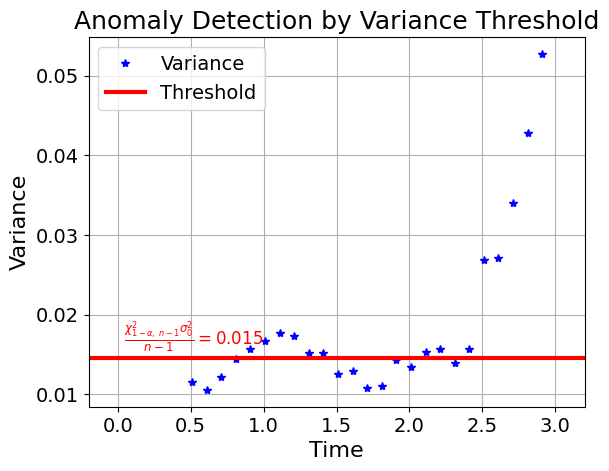

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import scipy.stats as stats

rawData = loadmat('/content/drive/MyDrive/PHM SUNYK/Datasets/xf_anomaly.mat')
xf = rawData['xf'].flatten()
t = rawData['t'].flatten()
N = len(xf)

al = 0.1      # significance level
n = 50        # window size

v0 = np.var(xf[:n], ddof=1)
c = stats.chi2.ppf(1 - al, n - 1)
vth = c * v0 / (n - 1)

# =========================
# 3. Moving-window statistics
# =========================
X2 = np.full(N, np.nan)
v = np.full(N, np.nan)

for i in range(n, N, 10):
    xw = xf[i-n:i]
    vk = np.var(xw, ddof=1)
    v[i] = vk
    X2[i] = (n - 1) * vk / v0

xp = t[n:N:10]
yp_x2 = X2[n:N:10]
yp_v = v[n:N:10]

# =========================
# 4. Plot 1: Chi-square statistic
# =========================
plt.figure()
plt.plot(xp, yp_x2, 'b*', label=r'$\chi^2$ statistic')
plt.axhline(c, color='r', linestyle='-', linewidth=3, label='Threshold')

plt.text(
    t[0] + 0.03, c + 10,
    rf'$\chi^2_{{1-\alpha,\;n-1}} = {c:.3f}$',
    color='r',fontsize=12,
)

plt.legend()
plt.grid(True)
plt.xlabel('Time')
plt.ylabel(r'$\chi^2$ statistic')
plt.title('Anomaly Detection by Chi-square Test')
plt.xlim([-0.2, 3.2])
plt.show()

# =========================
# 5. Plot 2: Variance with threshold
# =========================
plt.figure()
plt.plot(xp, yp_v, 'b*', label='Variance')
plt.axhline(vth, color='r', linestyle='-', linewidth=3, label='Threshold')

plt.text(
    t[0] + 0.03, vth + 0.03 * np.nanmax(yp_v),
    rf'$\frac{{\chi^2_{{1-\alpha,\;n-1}}\sigma_0^2}}{{n-1}} = {vth:.3f}$',
    color='r',fontsize=12,
)

plt.legend()
plt.grid(True)
plt.xlabel('Time')
plt.ylabel('Variance')
plt.title('Anomaly Detection by Variance Threshold')
plt.xlim([-0.2, 3.2])
plt.show()

### what is chi2inv ?

In [ ]:
import scipy.stats as stats
import ipywidgets as widgets
from ipywidgets import interact

def show_chi2inv(a=0.1, n=50):
    c = stats.chi2.ppf(1 - a, n - 1)
    print(f'chi2inv(1-a, n-1) = {c:.6f}')

interact(
    show_chi2inv,
    a=widgets.FloatSlider(value=0.1, min=0.001, max=0.3, step=0.001),
    n=widgets.IntSlider(value=50, min=2, max=300, step=1)
)

interactive(children=(FloatSlider(value=0.1, description='a', max=0.3, min=0.001, step=0.001), IntSlider(value…

<function __main__.show_chi2inv(a=0.1, n=50)>

### FA and MD

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import ipywidgets as widgets
from ipywidgets import interact

def plot_normal_with_threshold(p=0.90):
    mu = 0
    sigma = 1

    # threshold: left cumulative probability = p
    z_p = norm.ppf(p, loc=mu, scale=sigma)
    alpha = 1 - p   # right-tail area

    x = np.linspace(-4, 4, 2000)
    y = norm.pdf(x, loc=mu, scale=sigma)

    x_left = x[x <= z_p]
    y_left = norm.pdf(x_left, loc=mu, scale=sigma)

    x_right = x[x >= z_p]
    y_right = norm.pdf(x_right, loc=mu, scale=sigma)

    plt.figure(figsize=(9, 5))

    # PDF curve
    plt.plot(x, y, color='black', linewidth=2)

    # Fill areas
    plt.fill_between(x_left, y_left, 0, color='green', alpha=0.7)
    plt.fill_between(x_right, y_right, 0, color='red', alpha=0.7)

    # Threshold line
    plt.axvline(z_p, color='black', linestyle='--', linewidth=2)

    # Text inside green region
    plt.text(-0.9, 0.18, 'Normal region', fontsize=16, weight='bold')

    # Threshold annotation
    plt.annotate('Threshold',
                 xy=(z_p, 0.30),
                 xytext=(z_p + 0.55, 0.36),
                 fontsize=16,
                 arrowprops=dict(arrowstyle='->', lw=2))

    # Red area annotation
    x_arrow = z_p + 0.35
    y_arrow = norm.pdf(x_arrow, mu, sigma) * 0.55

    plt.annotate(fr'$\alpha = 1-p = {alpha:.2f}$',
                 xy=(x_arrow, y_arrow),
                 xytext=(z_p + 0.7, 0.16),
                 color='red',
                 fontsize=16,
                 arrowprops=dict(arrowstyle='->', color='red', lw=2))

    plt.xlabel('Feature Magnitude', fontsize=15)
    plt.ylabel('PDF', fontsize=15)
    plt.title(fr'Standard Normal Distribution $N(0,1)$,   $p={p:.2f}$,   $z_p={z_p:.3f}$',
              fontsize=16)
    plt.xlim(-4, 4)
    plt.ylim(0, 0.43)
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=13)
    plt.grid(alpha=0.3)
    plt.show()

interact(
    plot_normal_with_threshold,
    p=widgets.FloatSlider(
        value=0.90,
        min=0.50,
        max=0.99,
        step=0.01,
        description='p',
        readout_format='.2f',
        continuous_update=False
    )
)

interactive(children=(FloatSlider(value=0.9, continuous_update=False, description='p', max=0.99, min=0.5, step…

<function __main__.plot_normal_with_threshold(p=0.9)>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import ipywidgets as widgets
from ipywidgets import interact

def plot_two_distributions(p=0.90):
    # =========================================================
    # Distribution parameters
    # =========================================================
    mu1, sigma1 = 0, 1          # Healthy: N(0,1)
    mu2, sigma2 = 3, 1.2        # Faulty:  N(3,1.2)

    # Threshold from standard normal using p
    z_p = norm.ppf(p, loc=mu1, scale=sigma1)

    # False alarm and missed detection probabilities
    alpha = 1 - p
    beta = norm.cdf(z_p, loc=mu2, scale=sigma2)

    # =========================================================
    # PDF curves
    # =========================================================
    x = np.linspace(-4, 8, 3000)

    y1 = norm.pdf(x, loc=mu1, scale=sigma1)
    y2 = norm.pdf(x, loc=mu2, scale=sigma2)

    # Healthy left/right regions
    x1_left = x[x <= z_p]
    y1_left = norm.pdf(x1_left, loc=mu1, scale=sigma1)

    x1_right = x[x >= z_p]
    y1_right = norm.pdf(x1_right, loc=mu1, scale=sigma1)

    # Faulty left/right regions
    x2_left = x[x <= z_p]
    y2_left = norm.pdf(x2_left, loc=mu2, scale=sigma2)

    x2_right = x[x >= z_p]
    y2_right = norm.pdf(x2_right, loc=mu2, scale=sigma2)

    # =========================================================
    # Plot
    # =========================================================
    plt.figure(figsize=(10, 5.5))

    # Fill areas first
    plt.fill_between(x1_left, y1_left, 0, color='green', alpha=0.35)
    plt.fill_between(x1_right, y1_right, 0, color='red', alpha=0.35)

    plt.fill_between(x2_left, y2_left, 0, color='red', alpha=0.35)
    plt.fill_between(x2_right, y2_right, 0, color='green', alpha=0.20)

    # Curves on top so they are not hidden
    plt.plot(x, y1, color='black', linewidth=2, label=r'Healthy: $N(0,1)$')
    plt.plot(x, y2, color='blue', linewidth=2, label=r'Faulty: $N(3,1.2)$')

    # Threshold line
    plt.axvline(z_p, color='black', linestyle='--', linewidth=2)

    # =========================================================
    # Text and arrows
    # =========================================================
    ymax = max(np.max(y1), np.max(y2))

    # Threshold annotation
    plt.annotate('Threshold',
                 xy=(z_p, ymax*0.72),
                 xytext=(z_p + 0.45, ymax*0.90),
                 fontsize=14,
                 arrowprops=dict(arrowstyle='->', lw=2))

    # Alpha annotation on right tail of healthy distribution
    x_alpha = z_p + 0.55
    y_alpha = norm.pdf(x_alpha, mu1, sigma1) * 0.65
    plt.annotate(fr'$\alpha = 1-p = {alpha:.2f}$',
                 xy=(x_alpha, y_alpha),
                 xytext=(z_p + 0.9, ymax*0.42),
                 color='red',
                 fontsize=14,
                 arrowprops=dict(arrowstyle='->', color='red', lw=2))

    # Beta annotation on left side of faulty distribution
    x_beta = z_p - 0.35
    y_beta = norm.pdf(x_beta, mu2, sigma2) * 0.55
    plt.annotate(fr'$\beta = {beta:.2f}$',
                 xy=(x_beta, y_beta),
                 xytext=(z_p - 2.2, ymax*0.55),
                 color='red',
                 fontsize=14,
                 arrowprops=dict(arrowstyle='->', color='red', lw=2))

    # Region labels
    plt.text(-1.2, ymax*0.63, 'P(MD) = P(FN)', fontsize=14)
    plt.text(2.2, ymax*0.50, 'P(FA) = P(FP)', fontsize=14, color='blue')

    # Axes and title
    plt.xlabel('Feature Magnitude', fontsize=14)
    plt.ylabel('PDF', fontsize=14)
    plt.title(
        fr'Two Normal Distributions with Threshold  '
        fr'($p={p:.2f},\ z_p={z_p:.3f},\ \alpha={alpha:.2f},\ \beta={beta:.2f}$)',
        fontsize=15
    )
    plt.xlim(-4, 8)
    plt.ylim(0, ymax*1.15)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(alpha=0.3)
    plt.legend(fontsize=12)
    plt.show()

interact(
    plot_two_distributions,
    p=widgets.FloatSlider(
        value=0.90,
        min=0.50,
        max=0.99,
        step=0.01,
        description='p',
        readout_format='.2f',
        continuous_update=False
    )
)

interactive(children=(FloatSlider(value=0.9, continuous_update=False, description='p', max=0.99, min=0.5, step…

<function __main__.plot_two_distributions(p=0.9)>

### SPRT

mu0    = -0.0122
sigma0 = 0.1071
M      = 0.3213
A      = 2.2513
B      = -2.8904


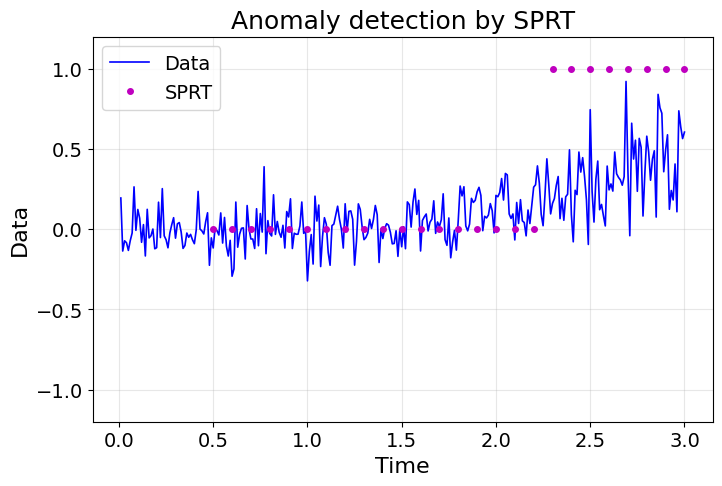

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

# =========================================================
# 1. Load data
# =========================================================
rawData = loadmat('/content/drive/MyDrive/PHM SUNYK/Datasets/xf_anomaly.mat')
xf = rawData['xf'].flatten()
t  = rawData['t'].flatten()

# =========================================================
# 2. Parameters
# =========================================================
alpha = 0.1
beta  = 0.05

N0 = 50               # baseline length
win = 50              # SPRT window length
step = 10             # moving step

mu0 = np.mean(xf[:N0])
sigma0 = np.std(xf[:N0], ddof=1)
M = sigma0*3

# SPRT thresholds
A = np.log((1 - beta) / alpha)
B = np.log(beta / (1 - alpha))

print(f'mu0    = {mu0:.4f}')
print(f'sigma0 = {sigma0:.4f}')
print(f'M      = {M:.4f}')
print(f'A      = {A:.4f}')
print(f'B      = {B:.4f}')

# =========================================================
# 3. SPRT decision function for one window
#    H0 : x ~ N(mu0, sigma0^2)
#    H1+: x ~ N(mu0 + M, sigma0^2)
#    H1-: x ~ N(mu0 - M, sigma0^2)
# =========================================================
def sprt_window_decision(xw, mu0, sigma0, M, A, B):
    """
    Return:
        +1 : positive anomaly
         0 : normal / undecided
        -1 : negative anomaly
    """
    s_pos = 0.0
    s_neg = 0.0

    for x in xw:
        # log-likelihood ratio increment for positive mean shift
        llr_pos = ((x - mu0) * M - 0.5 * M**2) / (sigma0**2)

        # log-likelihood ratio increment for negative mean shift
        llr_neg = (-(x - mu0) * M - 0.5 * M**2) / (sigma0**2)

        s_pos += llr_pos
        s_neg += llr_neg

        # positive anomaly
        if s_pos >= A:
            return +1

        # negative anomaly
        if s_neg >= A:
            return -1

        # if both strongly support H0, keep checking until window end
        # because opposite sign anomaly may still emerge later

    # final decision after the whole window
    if s_pos >= A:
        return +1
    elif s_neg >= A:
        return -1
    else:
        return 0

# =========================================================
# 4. Moving-window SPRT
# =========================================================
t_sprt = []
y_sprt = []

for end_idx in range(N0, len(xf) + 1, step):
    start_idx = end_idx - win
    if start_idx < 0:
        continue

    xw = xf[start_idx:end_idx]
    dec = sprt_window_decision(xw, mu0, sigma0, M, A, B)

    # plot time at the end of each window
    t_sprt.append(t[end_idx - 1])
    y_sprt.append(dec)

t_sprt = np.array(t_sprt)
y_sprt = np.array(y_sprt)

# =========================================================
# 5. Plot
# =========================================================
plt.figure(figsize=(8, 5))

plt.plot(t, xf, 'b', linewidth=1.2, label='Data')
plt.plot(t_sprt, y_sprt, 'mo', markersize=4, label='SPRT')

plt.xlabel('Time')
plt.ylabel('Data')
plt.title('Anomaly detection by SPRT')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(min(np.min(xf), -1.2), max(np.max(xf), 1.2))
plt.show()

## Distance based method

### Mahalanobis distance

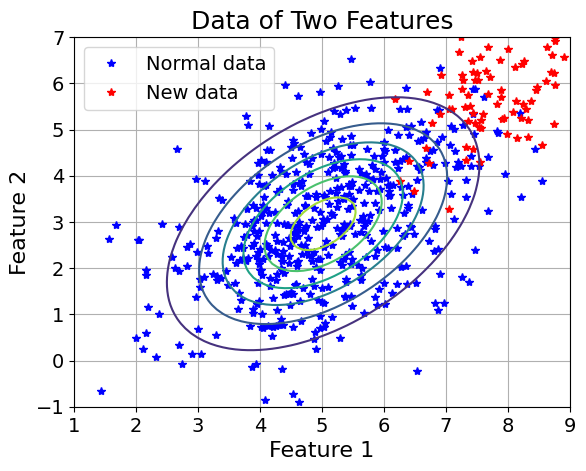

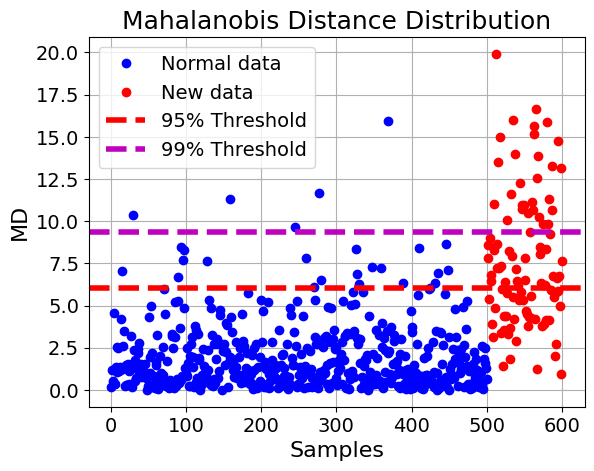

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal, f

# Parameters
Mu, S, n = [5, 3], [[2, 1], [1, 2]], 500              # Normal data
M1, S1, n1 = [8, 6], 0.5 * np.array([[2, 1], [1, 2]]), 100   # Fault data
np_features = 2
alpha_95 = 0.05   # 95% confidence level
alpha_99 = 0.01   # 99% confidence level

# Generate normal data and fault data
xx = np.random.multivariate_normal(Mu, S, n)
x1 = np.random.multivariate_normal(M1, S1, n1)

mean_xx = np.mean(xx, axis=0)
cov_xx = np.cov(xx.T)
inv_cov_xx = np.linalg.inv(cov_xx)

# Contour of normal data distribution
x, y = np.meshgrid(np.arange(1, 9.1, 0.1), np.arange(-1, 7.1, 0.1))
z = np.array([
    multivariate_normal.pdf([xi, yi], mean=mean_xx, cov=cov_xx)
    for xi, yi in zip(x.ravel(), y.ravel())
])
z = z.reshape(x.shape)

# Visualization of normal data vs fault data
plt.figure(1)
plt.plot(xx[:, 0], xx[:, 1], '*b', label='Normal data')
plt.plot(x1[:, 0], x1[:, 1], '*r', label='New data')
plt.contour(x, y, z)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Data of Two Features')
plt.grid(True)
plt.axis([
    -2 * S[0][0] + Mu[0], 2 * S[0][0] + Mu[0],
    -2 * S[1][1] + Mu[1], 2 * S[1][1] + Mu[1]
])
plt.legend()

# Mahalanobis distance calculation
MD = np.array([(x - mean_xx) @ inv_cov_xx @ (x - mean_xx) for x in xx])
MD_new = np.array([(x - mean_xx) @ inv_cov_xx @ (x - mean_xx) for x in x1])
MD = np.concatenate((MD, MD_new))

# Thresholds for 95% and 99% confidence levels
thresh_95 = ((n**2 - 1) * np_features / n / (n - np_features)
             * f.ppf(1 - alpha_95, np_features, n - np_features))
thresh_99 = ((n**2 - 1) * np_features / n / (n - np_features)
             * f.ppf(1 - alpha_99, np_features, n - np_features))

# Visualization of Mahalanobis distance distribution
plt.figure(2)
plt.plot(range(1, n + 1), MD[:n], 'o', color='b', label='Normal data')
plt.plot(range(n + 1, n + n1 + 1), MD[n:], 'or', label='New data')
plt.axhline(y=thresh_95, color='r', linestyle='--', linewidth=4, label='95% Threshold')
plt.axhline(y=thresh_99, color='m', linestyle='--', linewidth=4, label='99% Threshold')
plt.xlabel('Samples')
plt.ylabel('MD')
plt.title('Mahalanobis Distance Distribution')
plt.grid(True)
plt.legend()
plt.show()

## RK4 Anomaly detection

### BPFI BPFO calculation

In [ ]:
# ============================================================
# Reference only -- NOT used in the actual feature extraction.
# This purely geometric calculation (based on estimated, possibly
# inaccurate bearing dimensions D, d, theta) gives BPFO=116.4,
# BPFI=158.6 Hz, which do NOT match the empirically identified
# values actually used later (BPFO=97.0, BPFI=150.0 Hz in the
# "new BPFI" section). Kept here only to show why relying on
# estimated dimensions alone is unreliable; see the identified
# values in the "read RK4 & extract features (new BPFI)" cell
# for what is actually used.
# ============================================================
import numpy as np

# Given values
D = 25.0          # pitch diameter [mm]
d = 5.0           # ball diameter [mm]
theta_deg = 40.0  # contact angle [deg]
Z = 11            # number of balls
fr = 25.0         # shaft speed [Hz]

# Convert angle to radian
theta = np.deg2rad(theta_deg)

# Calculate BPFO and BPFI
BPFO = (Z / 2) * fr * (1 - (d / D) * np.cos(theta))
BPFI = (Z / 2) * fr * (1 + (d / D) * np.cos(theta))

print(f"BPFO = {BPFO:.3f} Hz")
print(f"BPFI = {BPFI:.3f} Hz")

BPFO = 116.434 Hz
BPFI = 158.566 Hz


### shaft 1X variation

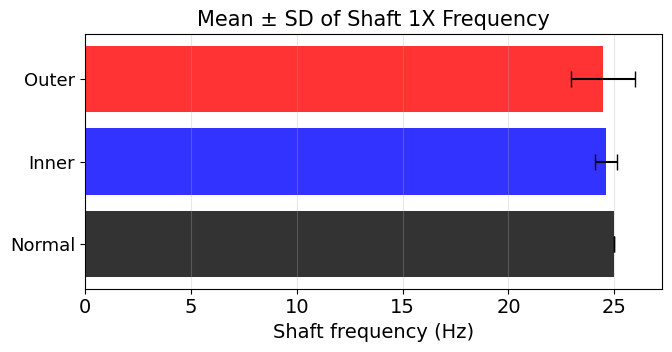

In [ ]:
from scipy.io import loadmat

# ============================================================
# 1. User settings
# ============================================================
file_in = '/content/drive/MyDrive/PHM SUNYK/Datasets/Raw_RK4.mat'

fs = 12800                 # Sampling frequency [Hz]
n_set = 20                 # Number of sets
n_per_set = 12800          # 1 second x 12.8 kHz
shaft_rpm_nom = 1500
shaft_hz_nom = shaft_rpm_nom / 60.0   # 25 Hz

shaft_search_range = 3.0   # +/- Hz around nominal shaft frequency

# ============================================================
# 2. Load mat file
# ============================================================
raw = loadmat(file_in)

# ============================================================
# 3. Extract actual shaft frequency [Hz] for each set
#    (uses the shared single_sided_fft / find_peak_near from
#    the "Settings and Utilities" section at the top)
# ============================================================
def extract_shaft_freq_allsets(x_concat, fs, n_set, n_per_set,
                                shaft_hz_nom, shaft_search_range, var_name='unknown'):
    x1d = make_1d_signal(x_concat, var_name)
    xset = split_into_sets(x1d, n_set, n_per_set, var_name)

    vals = np.zeros(n_set)
    for i in range(n_set):
        f, A = single_sided_fft(xset[i, :], fs)
        _, vals[i] = find_peak_near(f, A, shaft_hz_nom, shaft_search_range)
    return vals

shaftfreq_nor = extract_shaft_freq_allsets(
    raw['Nor'], fs, n_set, n_per_set, shaft_hz_nom, shaft_search_range, 'Nor'
)
shaftfreq_bin = extract_shaft_freq_allsets(
    raw['Bin'], fs, n_set, n_per_set, shaft_hz_nom, shaft_search_range, 'Bin'
)
shaftfreq_bout = extract_shaft_freq_allsets(
    raw['Bout'], fs, n_set, n_per_set, shaft_hz_nom, shaft_search_range, 'Bout'
)

# ============================================================
# 4. Mean and SD
# ============================================================
means = np.array([np.mean(shaftfreq_nor), np.mean(shaftfreq_bin), np.mean(shaftfreq_bout)])
errs = np.array([np.std(shaftfreq_nor, ddof=1), np.std(shaftfreq_bin, ddof=1), np.std(shaftfreq_bout, ddof=1)])
labels = ['Normal', 'Inner', 'Outer']
ypos = np.arange(len(labels))

# ============================================================
# 5. Horizontal bar plot
# ============================================================
plt.figure(figsize=(7.0, 3.8))
plt.barh(ypos, means, xerr=errs, color=['black', 'blue', 'red'], alpha=0.8, capsize=6)
plt.yticks(ypos, labels, fontsize=13)
plt.xlabel('Shaft frequency (Hz)', fontsize=14)
plt.title('Mean ± SD of Shaft 1X Frequency', fontsize=15)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


### shaft 1X~3X

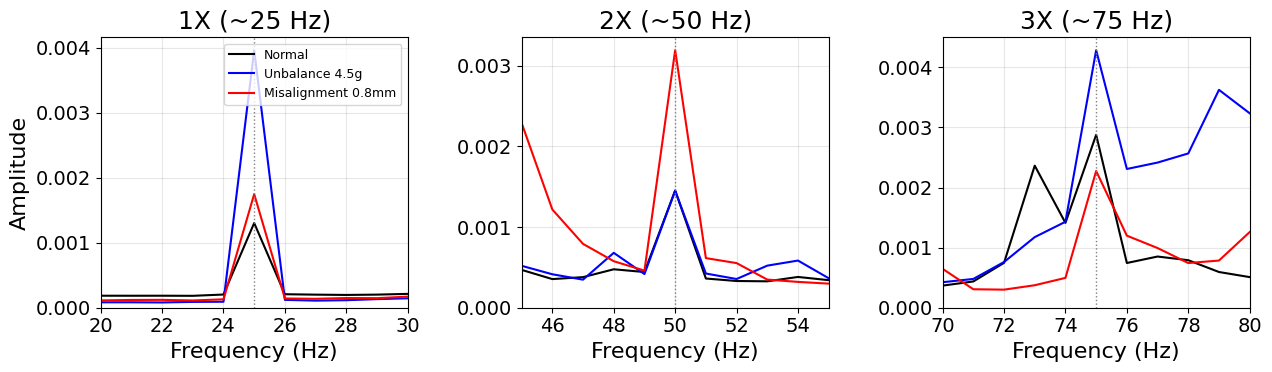

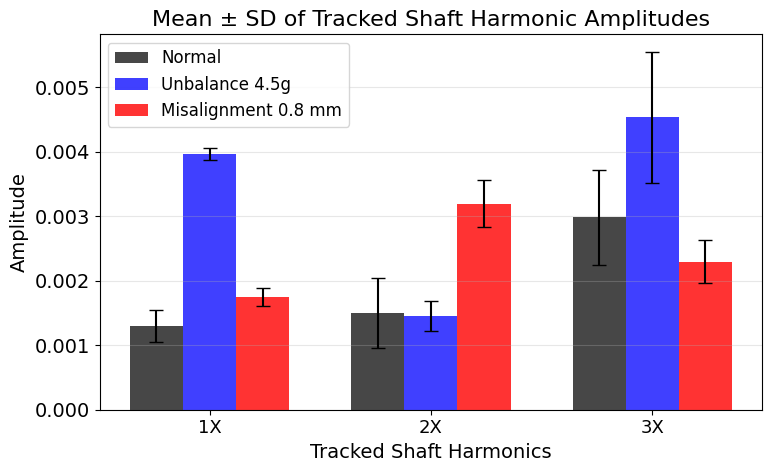

In [ ]:
from scipy.io import loadmat

# ============================================================
# 1. User settings
# ============================================================
file_in = '/content/drive/MyDrive/PHM SUNYK/Datasets/Raw_RK4.mat'

fs = 12800
n_set = 20
n_per_set = 12800

shaft_rpm_nom = 1500
shaft_hz_nom = shaft_rpm_nom / 60.0   # 25 Hz
shaft_nominal = np.array([1, 2, 3]) * shaft_hz_nom   # [25, 50, 75] Hz

shaft_search_range = 3.0
zoom_half_width = 5.0   # Hz, window half-width around each harmonic

# ============================================================
# 2. Load mat file
# ============================================================
raw = loadmat(file_in)

# ============================================================
# 3. Extract actual shaft harmonic (1X/2X/3X) frequencies and
#    amplitudes for each set (uses the shared single_sided_fft /
#    find_peak_near from the "Settings and Utilities" section)
# ============================================================
def extract_shaft_harmonics_allsets(x_concat, fs, n_set, n_per_set,
                                     shaft_hz_nom, shaft_search_range, var_name='unknown'):
    x1d = make_1d_signal(x_concat, var_name)
    xset = split_into_sets(x1d, n_set, n_per_set, var_name)
    freqs = np.zeros((n_set, 3))
    amps = np.zeros((n_set, 3))
    for i in range(n_set):
        f, A = single_sided_fft(xset[i, :], fs)
        for h in range(3):
            target = (h + 1) * shaft_hz_nom
            amps[i, h], freqs[i, h] = find_peak_near(f, A, target, shaft_search_range)
    return freqs, amps, xset

freq_nor, amp_nor, nor_set = extract_shaft_harmonics_allsets(
    raw['Nor'], fs, n_set, n_per_set, shaft_hz_nom, shaft_search_range, 'Nor'
)
freq_unb45, amp_unb45, unb45_set = extract_shaft_harmonics_allsets(
    raw['Unb45'], fs, n_set, n_per_set, shaft_hz_nom, shaft_search_range, 'Unb45'
)
freq_mis08, amp_mis08, mis08_set = extract_shaft_harmonics_allsets(
    raw['Mis08'], fs, n_set, n_per_set, shaft_hz_nom, shaft_search_range, 'Mis08'
)

# ============================================================
# 4. Zoomed-in comparison at each shaft harmonic (1X, 2X, 3X)
#    Each harmonic is shown in its own narrow window so the
#    1X/2X/3X amplitudes can be compared directly across classes,
#    without unrelated peaks (e.g. ~41, ~82 Hz) dominating the view.
# ============================================================
fN, XN = mean_spectrum_across_sets(nor_set, fs)
fU, XU = mean_spectrum_across_sets(unb45_set, fs)
fM, XM = mean_spectrum_across_sets(mis08_set, fs)

fig, axs = plt.subplots(1, 3, figsize=(13, 4))
for col, (order, f0) in enumerate(zip([1, 2, 3], shaft_nominal)):
    lo, hi = f0 - zoom_half_width, f0 + zoom_half_width
    idxN = (fN >= lo) & (fN <= hi)
    idxU = (fU >= lo) & (fU <= hi)
    idxM = (fM >= lo) & (fM <= hi)
    ymax = 1.05 * max(np.max(XN[idxN]), np.max(XU[idxU]), np.max(XM[idxM]))

    axs[col].plot(fN[idxN], XN[idxN], 'k', lw=1.5, label='Normal')
    axs[col].plot(fU[idxU], XU[idxU], 'b', lw=1.5, label='Unbalance 4.5g')
    axs[col].plot(fM[idxM], XM[idxM], 'r', lw=1.5, label='Misalignment 0.8mm')
    axs[col].axvline(f0, color='gray', linestyle=':', lw=1)
    axs[col].set_xlim(lo, hi)
    axs[col].set_ylim(0, ymax)
    axs[col].set_title(f'{order}X (~{f0:.0f} Hz)')
    axs[col].set_xlabel('Frequency (Hz)')
    axs[col].grid(alpha=0.3)
    if col == 0:
        axs[col].set_ylabel('Amplitude')
        axs[col].legend(fontsize=9)
plt.tight_layout()
plt.show()

# ============================================================
# 5. Mean +/- SD bar chart
# ============================================================
mean_nor, mean_unb45, mean_mis08 = np.mean(amp_nor, axis=0), np.mean(amp_unb45, axis=0), np.mean(amp_mis08, axis=0)
std_nor, std_unb45, std_mis08 = np.std(amp_nor, axis=0, ddof=1), np.std(amp_unb45, axis=0, ddof=1), np.std(amp_mis08, axis=0, ddof=1)

harmonics = ['1X', '2X', '3X']
x = np.arange(len(harmonics))
w = 0.24

plt.figure(figsize=(8, 5))
plt.bar(x - w, mean_nor, width=w, yerr=std_nor, capsize=5, color='#333333', alpha=0.9, label='Normal')
plt.bar(x, mean_unb45, width=w, yerr=std_unb45, capsize=5, color='blue', alpha=0.75, label='Unbalance 4.5g')
plt.bar(x + w, mean_mis08, width=w, yerr=std_mis08, capsize=5, color='red', alpha=0.8, label='Misalignment 0.8 mm')
plt.xticks(x, harmonics, fontsize=13)
plt.ylabel('Amplitude', fontsize=14)
plt.xlabel('Tracked Shaft Harmonics', fontsize=14)
plt.title('Mean ± SD of Tracked Shaft Harmonic Amplitudes', fontsize=16)
plt.grid(axis='y', alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


### BFF with envelope



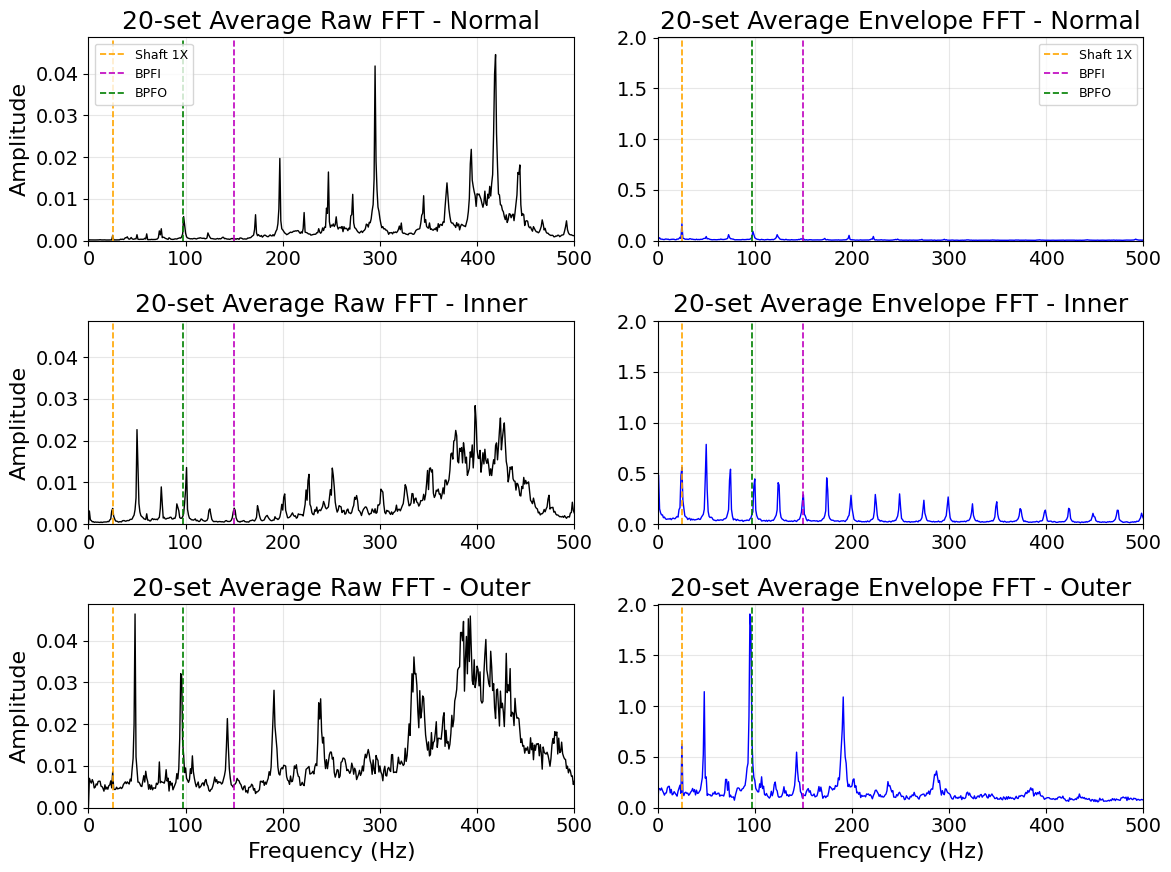

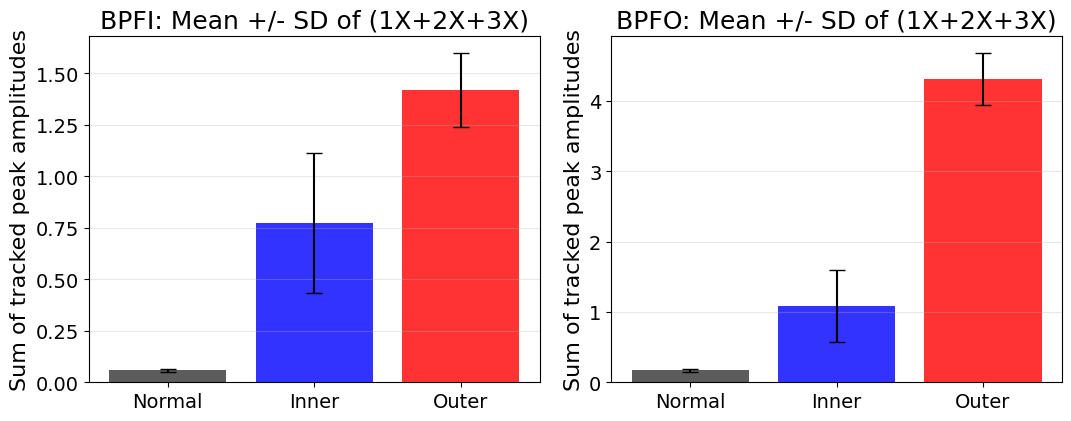

In [ ]:
from scipy.io import loadmat

# ============================================================
# 1. User settings
# ============================================================
file_in = '/content/drive/MyDrive/PHM SUNYK/Datasets/Raw_RK4.mat'

fs = 12800
n_set = 20
n_per_set = 12800

# Identified defect frequencies [Hz] (see "read RK4 & extract
# features (new BPFI)" section for how these were determined)
shaft_hz_ref = 25.0    # nominal/actual shaft speed (1X)
bpfo_ref = 97.0        # Identified BPFO candidate [Hz] at 25 Hz shaft
bpfi_ref = 150.0       # Identified BPFI center candidate [Hz] at 25 Hz shaft
                       # Note: close to the 6th shaft harmonic (6*25=150 Hz);
                       # could not be conclusively separated from it via
                       # sidebands. Kept as a reference value from prior
                       # identification, not a fully verified defect frequency.

xmax_plot = 500

# ============================================================
# 2. Load mat file and split into sets
# ============================================================
raw = loadmat(file_in)
nor_set = split_into_sets(make_1d_signal(raw['Nor'], 'Nor'), n_set, n_per_set, 'Nor')
bin_set = split_into_sets(make_1d_signal(raw['Bin'], 'Bin'), n_set, n_per_set, 'Bin')
bout_set = split_into_sets(make_1d_signal(raw['Bout'], 'Bout'), n_set, n_per_set, 'Bout')

# ============================================================
# 3. Key illustration: raw FFT vs envelope FFT, 20-set average
#    Shows that defect frequencies are hidden in the raw spectrum
#    but clearly revealed in the envelope spectrum.
#    Y-axis is unified within each column (raw / envelope) so
#    amplitudes are directly comparable across classes.
#    Only 1X reference lines (shaft, BPFI, BPFO) are marked --
#    harmonics are omitted here to keep the figure readable.
# ============================================================
sets = {'Normal': nor_set, 'Inner': bin_set, 'Outer': bout_set}

raw_results = {name: mean_spectrum_across_sets(xset, fs, single_sided_fft) for name, xset in sets.items()}
env_results = {name: mean_spectrum_across_sets(xset, fs, envelope_spectrum) for name, xset in sets.items()}

idx_raw_range = (raw_results['Normal'][0] >= 0) & (raw_results['Normal'][0] <= xmax_plot)
idx_env_range = (env_results['Normal'][0] >= 0) & (env_results['Normal'][0] <= xmax_plot)
ymax_raw = 1.05 * max(np.max(X[idx_raw_range]) for _, X in raw_results.values())
ymax_env = 1.05 * max(np.max(X[idx_env_range]) for _, X in env_results.values())

fig, axs = plt.subplots(3, 2, figsize=(12, 9))
col_specs = [('Raw', 'k', raw_results, ymax_raw), ('Envelope', 'b', env_results, ymax_env)]

for row, name in enumerate(sets.keys()):
    for col, (label, color, results, ymax) in enumerate(col_specs):
        f, X = results[name]
        idx = (f >= 0) & (f <= xmax_plot)
        axs[row, col].plot(f[idx], X[idx], color, lw=1)
        axs[row, col].axvline(shaft_hz_ref, color='orange', linestyle='--', lw=1.2, label='Shaft 1X' if row == 0 else None)
        axs[row, col].axvline(bpfi_ref, color='m', linestyle='--', lw=1.2, label='BPFI' if row == 0 else None)
        axs[row, col].axvline(bpfo_ref, color='g', linestyle='--', lw=1.2, label='BPFO' if row == 0 else None)
        axs[row, col].set_xlim(0, xmax_plot)
        axs[row, col].set_ylim(0, ymax)
        axs[row, col].set_title(f'20-set Average {label} FFT - {name}')
        axs[row, col].grid(alpha=0.3)
        if col == 0:
            axs[row, col].set_ylabel('Amplitude')
        if row == 0:
            axs[row, col].legend(fontsize=9)

axs[-1, 0].set_xlabel('Frequency (Hz)')
axs[-1, 1].set_xlabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

# ============================================================
# 4. Quantitative summary: sum of tracked peaks (1X+2X+3X)
#    across all 20 sets, mean +/- SD by class
# ============================================================
def track_harmonics_allsets(xset, fs, base_freq):
    """Track envelope-spectrum amplitude of 1X/2X/3X of base_freq, for all sets.
    Input : xset (n_set, n_per_set), fs, base_freq (Hz)
    Output: (n_set, 3) array of amplitudes
    """
    n_set = xset.shape[0]
    amps = np.zeros((n_set, 3))
    for i in range(n_set):
        f, A = envelope_spectrum(xset[i, :], fs)
        for h in range(3):
            amps[i, h], _ = find_peak_near(f, A, (h + 1) * base_freq, max(4.0, 0.06 * (h + 1) * base_freq))
    return amps

amp_bpfi = {name: track_harmonics_allsets(xset, fs, bpfi_ref) for name, xset in sets.items()}
amp_bpfo = {name: track_harmonics_allsets(xset, fs, bpfo_ref) for name, xset in sets.items()}

sum_bpfi = [np.sum(amp_bpfi[name], axis=1) for name in sets.keys()]
sum_bpfo = [np.sum(amp_bpfo[name], axis=1) for name in sets.keys()]

labels = list(sets.keys())
x = np.arange(len(labels))

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
axs[0].bar(x, [s.mean() for s in sum_bpfi], yerr=[s.std(ddof=1) for s in sum_bpfi],
           capsize=6, color=['#333333', 'blue', 'red'], alpha=0.8)
axs[0].set_xticks(x); axs[0].set_xticklabels(labels)
axs[0].set_ylabel('Sum of tracked peak amplitudes')
axs[0].set_title('BPFI: Mean +/- SD of (1X+2X+3X)')
axs[0].grid(axis='y', alpha=0.3)

axs[1].bar(x, [s.mean() for s in sum_bpfo], yerr=[s.std(ddof=1) for s in sum_bpfo],
           capsize=6, color=['#333333', 'blue', 'red'], alpha=0.8)
axs[1].set_xticks(x); axs[1].set_xticklabels(labels)
axs[1].set_ylabel('Sum of tracked peak amplitudes')
axs[1].set_title('BPFO: Mean +/- SD of (1X+2X+3X)')
axs[1].grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### Extract features with new BPFI

In [ ]:
from scipy.io import loadmat, savemat

# ============================================================
# This code is programmed by System Design Optimization Lab
# (SDOL) at Korea Aerospace University (KAU)
# ============================================================

# ============================================================
# 1. User settings
# ============================================================
file_in = '/content/drive/MyDrive/PHM SUNYK/Datasets/Raw_RK4.mat'
file_out = '/content/drive/MyDrive/PHM SUNYK/Datasets/Feat_RK4.mat'

fs = 12800
n_set = 20
n_per_set = 12800
shaft_hz_nom = 1500 / 60.0   # 25 Hz

# Actual identified bearing-fault center frequencies at nominal
# shaft speed (not theoretical nominal BFF values)
bpfi_center_ref = 150.0    # Identified BPFI center candidate [Hz] at 25 Hz shaft
bpfo_center_ref = 97.0     # Identified BPFO candidate [Hz] at 25 Hz shaft

# Search ranges
shaft_search_range = 3.0   # +/- Hz around shaft harmonics
inner_search_range = 5.0   # +/- Hz around each BPFI-1X/BPFI/BPFI+1X target
outer_search_ratio = 0.06  # +/- 6% around scaled BPFO harmonics
outer_search_min = 4.0     # minimum +/- Hz for BPFO harmonics

raw_var_names = ['Nor', 'Unb35', 'Unb45', 'Mis06', 'Mis08', 'Bin', 'Bout']
feat_var_names = ['FNor', 'FUnb35', 'FUnb45', 'FMis06', 'FMis08', 'FBin', 'FBout']
feature_names = [
    'Shaft1X', 'Shaft2X', 'Shaft3X',
    'BPFI-1X', 'BPFI', 'BPFI+1X',
    'BPFO', '2BPFO', '3BPFO'
]

# ============================================================
# 2. Feature extraction for one 1-second signal
#    (uses the shared single_sided_fft / envelope_spectrum /
#    find_peak_near from the "Settings and Utilities" section)
# ============================================================
def extract_9_features_one_set(x, fs, shaft_hz_nom, bpfi_center_ref, bpfo_center_ref):
    """Extract 9 features from one 1-second signal:
    [shaft 1X, shaft 2X, shaft 3X, BPFI-1X, BPFI, BPFI+1X, BPFO, 2BPFO, 3BPFO]

    Notes:
    - Shaft features come from the raw FFT.
    - Bearing fault features come from the envelope spectrum.
    - BPFI uses center +/- shaft-1X sidebands (amplitude modulation).
    - BPFO uses center harmonics only.
    - Actual identified center frequencies are used instead of
      theoretical nominal BFFs, then rescaled by each set's own
      actual shaft speed.
    """
    # Step 1: shaft features from raw FFT
    f_raw, A_raw = single_sided_fft(x, fs)
    shaft_amp_1x, shaft_freq_1x = find_peak_near(f_raw, A_raw, shaft_hz_nom, shaft_search_range)
    if np.isnan(shaft_freq_1x):
        shaft_freq_1x = shaft_hz_nom

    shaft_feats = []
    for k in [1, 2, 3]:
        amp, _ = find_peak_near(f_raw, A_raw, k * shaft_freq_1x, shaft_search_range)
        shaft_feats.append(amp)

    # Step 2: bearing fault features from envelope spectrum
    f_env, A_env = envelope_spectrum(x, fs)
    speed_ratio = shaft_freq_1x / shaft_hz_nom
    bpfi_center = bpfi_center_ref * speed_ratio
    bpfo_center = bpfo_center_ref * speed_ratio

    inner_targets = [bpfi_center - shaft_freq_1x, bpfi_center, bpfi_center + shaft_freq_1x]
    bpfi_feats = [find_peak_near(f_env, A_env, t, inner_search_range)[0] for t in inner_targets]

    bpfo_feats = []
    for k in [1, 2, 3]:
        target = k * bpfo_center
        df_bpfo = max(outer_search_min, outer_search_ratio * target)
        amp, _ = find_peak_near(f_env, A_env, target, df_bpfo)
        bpfo_feats.append(amp)

    # Step 3: return 9 features
    return np.array(shaft_feats + bpfi_feats + bpfo_feats, dtype=float)

# ============================================================
# 3. Load data and extract features for each class
# ============================================================
data = loadmat(file_in)
feat_data = {}

for raw_name, feat_name in zip(raw_var_names, feat_var_names):
    x_all = data[raw_name].flatten()
    if len(x_all) != n_set * n_per_set:
        raise ValueError(f'{raw_name} length is {len(x_all)}, but expected {n_set*n_per_set}.')

    F = np.zeros((n_set, 9))
    for i in range(n_set):
        i1, i2 = i * n_per_set, (i + 1) * n_per_set
        F[i, :] = extract_9_features_one_set(
            x_all[i1:i2], fs, shaft_hz_nom, bpfi_center_ref, bpfo_center_ref
        )

    feat_data[feat_name] = F
    print(f'{feat_name} saved with shape {F.shape}')

# ============================================================
# 4. Save feature data
# ============================================================
savemat(file_out, feat_data)
print('Feature extraction finished.')
print(f'Saved to: {file_out}')
print('Variables saved:', list(feat_data.keys()))
print('Feature order:', feature_names)


FNor saved with shape (20, 9)
FUnb35 saved with shape (20, 9)
FUnb45 saved with shape (20, 9)
FMis06 saved with shape (20, 9)
FMis08 saved with shape (20, 9)
FBin saved with shape (20, 9)
FBout saved with shape (20, 9)
Feature extraction finished.
Saved to: /content/drive/MyDrive/PHM SUNYK/Datasets/Feat_RK4.mat
Variables saved: ['FNor', 'FUnb35', 'FUnb45', 'FMis06', 'FMis08', 'FBin', 'FBout']
Feature order: ['Shaft1X', 'Shaft2X', 'Shaft3X', 'BPFI-1X', 'BPFI', 'BPFI+1X', 'BPFO', '2BPFO', '3BPFO']


### MD of each classes

Number of features p = 9
MD^2 threshold at alpha=0.01 = 75.5994


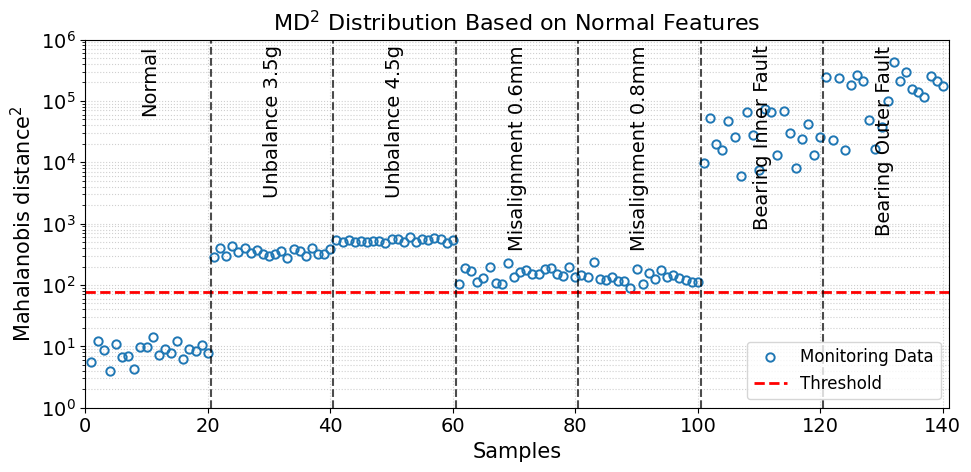

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.stats import chi2
from scipy.stats import f

# ============================================================
# 1. Load feature data
# ============================================================
file_feat = '/content/drive/MyDrive/PHM SUNYK/Datasets/Feat_RK4.mat'
data = loadmat(file_feat)

FNor   = data['FNor']
FUnb35 = data['FUnb35']
FUnb45 = data['FUnb45']
FMis06 = data['FMis06']
FMis08 = data['FMis08']
FBin   = data['FBin']
FBout  = data['FBout']

# ============================================================
# 2. Calculate mean and covariance from normal condition only
# ============================================================
mu = np.mean(FNor, axis=0)
cov = np.cov(FNor.T)
inv_cov = np.linalg.inv(cov)

# Number of features
n = FNor.shape[0]
p = FNor.shape[1]

# Threshold for MD^2 at significance level alpha = 0.01
alpha = 0.01
# threshold = chi2.ppf(1 - alpha, df=p) # chi2 version
threshold = (
    p * (n + 1) * (n - 1)
    / (n * (n - p))
    * f.ppf(1 - alpha, p, n - p)
)

print(f'Number of features p = {p}')
print(f'MD^2 threshold at alpha={alpha} = {threshold:.4f}')

# ============================================================
# 3. Function to calculate MD^2
# ============================================================
def mahalanobis_squared(X, mu, inv_cov):
    """
    X: (n_samples, n_features)
    return: MD^2 of shape (n_samples,)
    """
    D = X - mu
    md2 = np.sum((D @ inv_cov) * D, axis=1)
    return md2

# ============================================================
# 4. Calculate MD^2 for all conditions
# ============================================================
MD2_Nor   = mahalanobis_squared(FNor,   mu, inv_cov)
MD2_Unb35 = mahalanobis_squared(FUnb35, mu, inv_cov)
MD2_Unb45 = mahalanobis_squared(FUnb45, mu, inv_cov)
MD2_Mis06 = mahalanobis_squared(FMis06, mu, inv_cov)
MD2_Mis08 = mahalanobis_squared(FMis08, mu, inv_cov)
MD2_Bin   = mahalanobis_squared(FBin,   mu, inv_cov)
MD2_Bout  = mahalanobis_squared(FBout,  mu, inv_cov)

# Concatenate all MD^2 values
MD2_all = np.concatenate([
    MD2_Nor, MD2_Unb35, MD2_Unb45,
    MD2_Mis06, MD2_Mis08, MD2_Bin, MD2_Bout
])

# ============================================================
# 5. Build x-axis and section boundaries
# ============================================================
n_each = FNor.shape[0]   # should be 20
x_all = np.arange(1, len(MD2_all) + 1)

# Section boundaries
b1 = n_each
b2 = 2 * n_each
b3 = 3 * n_each
b4 = 4 * n_each
b5 = 5 * n_each
b6 = 6 * n_each
b7 = 7 * n_each

# Centers for labels
c1 = (1 + b1) / 2
c2 = (b1 + 1 + b2) / 2
c3 = (b2 + 1 + b3) / 2
c4 = (b3 + 1 + b4) / 2
c5 = (b4 + 1 + b5) / 2
c6 = (b5 + 1 + b6) / 2
c7 = (b6 + 1 + b7) / 2

# ============================================================
# 6. Plot
# ============================================================
plt.figure(figsize=(10, 5))

plt.semilogy(
    x_all, MD2_all, 'o',
    markerfacecolor='none',
    markeredgecolor='tab:blue',
    markeredgewidth=1.4,
    markersize=6,
    label='Monitoring Data'
)

plt.axhline(
    y=threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Threshold'
)

# Vertical boundaries between classes
for xb in [b1 + 0.5, b2 + 0.5, b3 + 0.5, b4 + 0.5, b5 + 0.5, b6 + 0.5]:
    plt.axvline(x=xb, color='k', linestyle='--', linewidth=1.5, alpha=0.7)

# Labels for each class
y_text = 8e5
plt.text(c1, y_text, 'Normal', rotation=90, ha='center', va='top', fontsize=14)
plt.text(c2, y_text, 'Unbalance 3.5g', rotation=90, ha='center', va='top', fontsize=14)
plt.text(c3, y_text, 'Unbalance 4.5g', rotation=90, ha='center', va='top', fontsize=14)
plt.text(c4, y_text, 'Misalignment 0.6mm', rotation=90, ha='center', va='top', fontsize=14)
plt.text(c5, y_text, 'Misalignment 0.8mm', rotation=90, ha='center', va='top', fontsize=14)
plt.text(c6, y_text, 'Bearing Inner Fault', rotation=90, ha='center', va='top', fontsize=14)
plt.text(c7, y_text, 'Bearing Outer Fault', rotation=90, ha='center', va='top', fontsize=14)

plt.xlabel('Samples', fontsize=15)
plt.ylabel(r'Mahalanobis distance$^2$', fontsize=15)
plt.title(r'MD$^2$ Distribution Based on Normal Features', fontsize=16)

plt.xlim(0, len(MD2_all) + 1)
plt.ylim(1e0, 1e6)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='lower right')
plt.tight_layout()
plt.show()

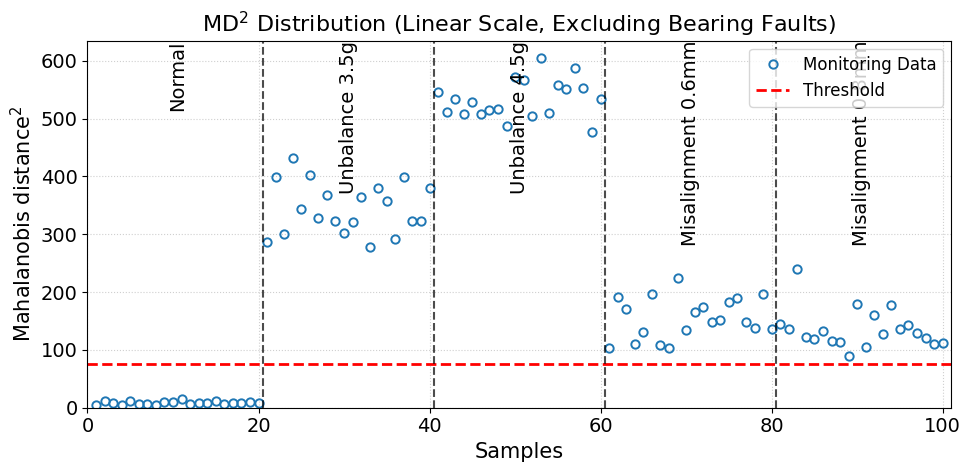

In [ ]:
# ============================================================
# 7. Additional plot: original scale (linear), excluding bearing faults
# ============================================================
MD2_no_bearing = np.concatenate([
    MD2_Nor, MD2_Unb35, MD2_Unb45,
    MD2_Mis06, MD2_Mis08
])

x_no_bearing = np.arange(1, len(MD2_no_bearing) + 1)

# Section boundaries
b1_nb = n_each
b2_nb = 2 * n_each
b3_nb = 3 * n_each
b4_nb = 4 * n_each
b5_nb = 5 * n_each

# Centers for labels
c1_nb = (1 + b1_nb) / 2
c2_nb = (b1_nb + 1 + b2_nb) / 2
c3_nb = (b2_nb + 1 + b3_nb) / 2
c4_nb = (b3_nb + 1 + b4_nb) / 2
c5_nb = (b4_nb + 1 + b5_nb) / 2

plt.figure(figsize=(10, 5))

plt.plot(
    x_no_bearing, MD2_no_bearing, 'o',
    markerfacecolor='none',
    markeredgecolor='tab:blue',
    markeredgewidth=1.4,
    markersize=6,
    label='Monitoring Data'
)

plt.axhline(
    y=threshold,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Threshold'
)

# Vertical boundaries between classes
for xb in [b1_nb + 0.5, b2_nb + 0.5, b3_nb + 0.5, b4_nb + 0.5]:
    plt.axvline(x=xb, color='k', linestyle='--', linewidth=1.5, alpha=0.7)

# Labels for each class
ymax_nb = max(np.max(MD2_no_bearing), threshold) * 1.05

plt.text(c1_nb, ymax_nb, 'Normal', rotation=90, ha='center', va='top', fontsize=14)
plt.text(c2_nb, ymax_nb, 'Unbalance 3.5g', rotation=90, ha='center', va='top', fontsize=14)
plt.text(c3_nb, ymax_nb, 'Unbalance 4.5g', rotation=90, ha='center', va='top', fontsize=14)
plt.text(c4_nb, ymax_nb, 'Misalignment 0.6mm', rotation=90, ha='center', va='top', fontsize=14)
plt.text(c5_nb, ymax_nb, 'Misalignment 0.8mm', rotation=90, ha='center', va='top', fontsize=14)

plt.xlabel('Samples', fontsize=15)
plt.ylabel(r'Mahalanobis distance$^2$', fontsize=15)
plt.title(r'MD$^2$ Distribution (Linear Scale, Excluding Bearing Faults)', fontsize=16)

plt.xlim(0, len(MD2_no_bearing) + 1)
plt.ylim(0, ymax_nb)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12, loc='upper right')
plt.tight_layout()
plt.show()

## ISO 10816

### read CWRU bearing

In [5]:
import pandas as pd

# Load data
file_in = '/content/drive/MyDrive/PHM SUNYK/Datasets/Bearing_CWRU/bearing_data.csv'
data = pd.read_csv(file_in).to_numpy()  # convert CSV file to a NumPy array


### velocity by simple integration

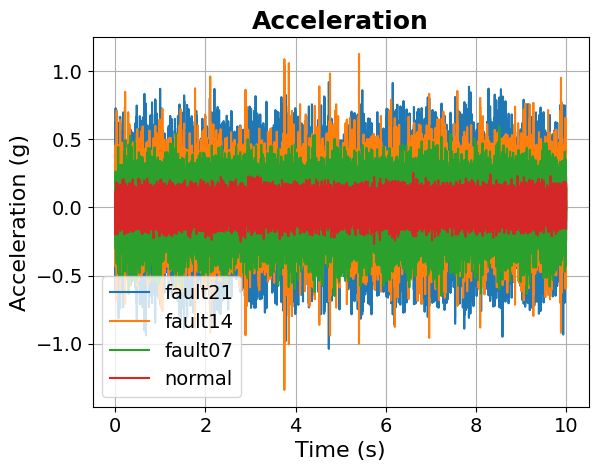

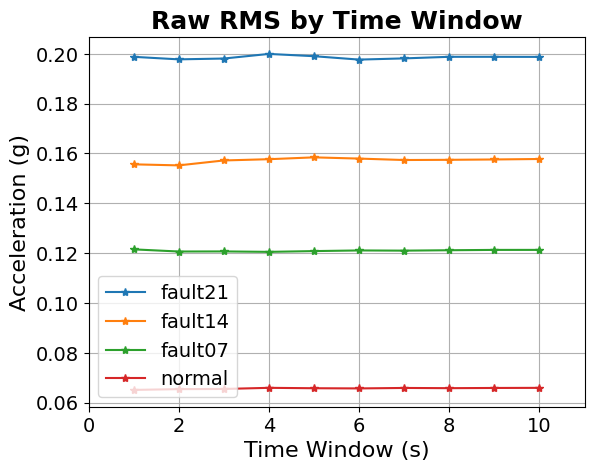

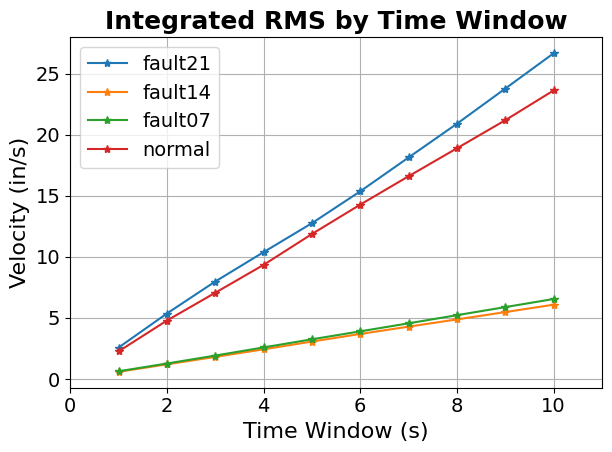

In [8]:
from scipy.integrate import cumulative_trapezoid

# ============================================================
# Data preprocessing
# ============================================================
time_data = data[:, 0]
num_samples = len(time_data)
sampling_rate = num_samples / time_data[-1]
scaling_factor = 386.2205

# ============================================================
# RMS and integrated RMS calculation (time-domain analysis)
# ============================================================
rms_raw = []
rms_integrated = []

for window in range(1, 11):
    end_idx = np.where(time_data >= window)[0][0] + 1
    start_idx = 0

    time_window = time_data[start_idx:end_idx]
    accel_data = data[start_idx:end_idx, 1:5]

    integrated_data = cumulative_trapezoid(accel_data, time_window, axis=0, initial=0)

    rms_raw.append(np.sqrt(np.mean(accel_data**2, axis=0)))
    rms_integrated.append(np.sqrt(np.mean(integrated_data**2, axis=0)) * scaling_factor)

rms_raw = np.array(rms_raw)
rms_integrated = np.array(rms_integrated)

# ============================================================
# Visualization (uses the shared plot_data helper from the
# "Settings and Utilities" section at the top of the notebook)
# ============================================================
labels = ['fault21', 'fault14', 'fault07', 'normal']
plot_data(time_data, data[:, 1:5], labels, 'Acceleration (g)', 'Time (s)', 'Acceleration', figure_num=1)
plot_data(range(1, 11), rms_raw, labels, 'Acceleration (g)', 'Time Window (s)', 'Raw RMS by Time Window',
          figure_num=2, xlim=[0, len(rms_raw) + 1], marker='*-')
plot_data(range(1, 11), rms_integrated, labels, 'Velocity (in/s)', 'Time Window (s)', 'Integrated RMS by Time Window',
          figure_num=3, xlim=[0, len(rms_raw) + 1], marker='*-')
plt.tight_layout()
plt.show()


### velocity by PSD

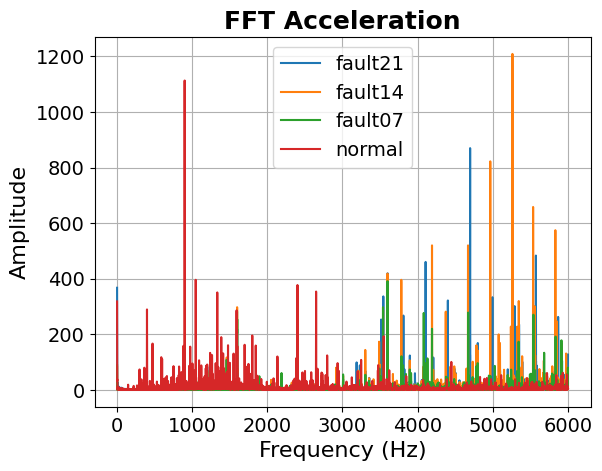

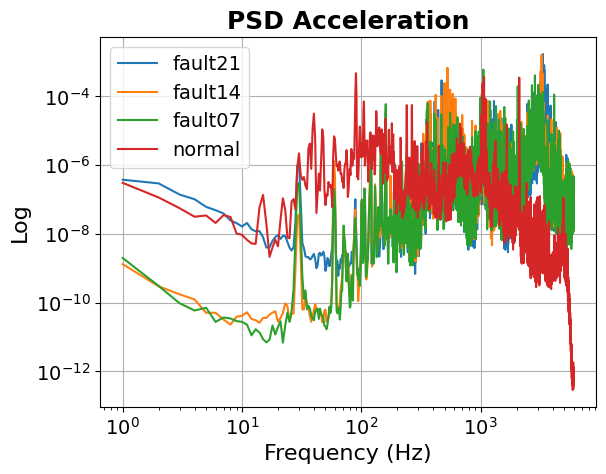

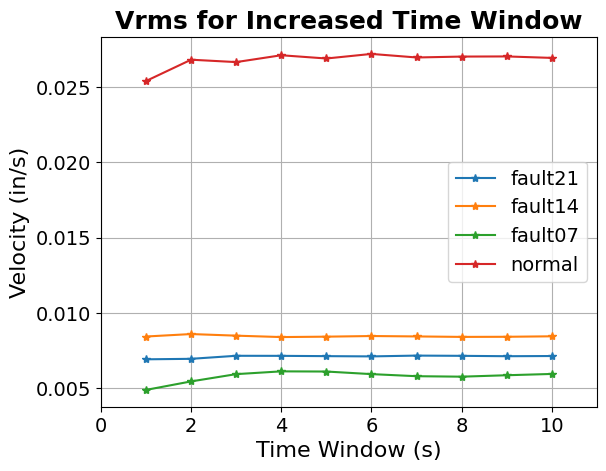

In [16]:
import numpy as np
import scipy.signal

# Frequency-domain analysis
rms_psd = []  # List to store RMS results
psd_list = []  # List to store PSD results

for data_type in range(1, 5):  # Four data types
    for cycle in range(1, 11):  # Ten cycles
        end_idx = np.where(time_data >= cycle)[0][0] + 1  # End index of the current cycle
        start_idx = 0  # Start index of the current cycle

        time_window = time_data[start_idx:end_idx]  # Extract time data
        accel_data = data[start_idx:end_idx, data_type]  # Extract acceleration data

        # Perform frequency-domain analysis using Welch's method
        freq, psd = scipy.signal.welch(
            accel_data,
            fs=sampling_rate,
            window='hann',
            nperseg=sampling_rate,
            noverlap=0,
            nfft=sampling_rate
        )
        vpsd = psd[1:] / (2 * np.pi * freq[1:])**2  # Compute velocity power spectral density
        vpsd *= scaling_factor**2  # Apply scaling

        rms_psd.append(np.sqrt(np.sum(vpsd[10:1000])))  # Compute and store RMS

    psd_list.append(psd)  # Store PSD result

# Compute FFT
hann_window = np.hanning(len(time_window))  # Hann window
fft_result = np.abs(np.fft.fft(data[:, 1:5] * hann_window[:, np.newaxis], axis=0))  # Perform FFT

# Convert lists to NumPy arrays
psd_array = np.column_stack(psd_list)
rms_psd = np.array(rms_psd).reshape(4, 10).T  # Reshape RMS results for plotting

# Visualization
plot_data(freq[1:], fft_result[1:6001, :], labels, 'Amplitude', 'Frequency (Hz)', 'FFT Acceleration', figure_num=1)
plot_data(freq[1:], psd_array[1:, :], labels, 'Log', 'Frequency (Hz)', 'PSD Acceleration', figure_num=2, plot_type=2)
plot_data(range(1, 11), rms_psd, labels, 'Velocity (in/s)', 'Time Window (s)', 'Vrms for Increased Time Window', figure_num=3, xlim=[0, 11], marker='*-')
plt.show()

### RK4 ISO 10816

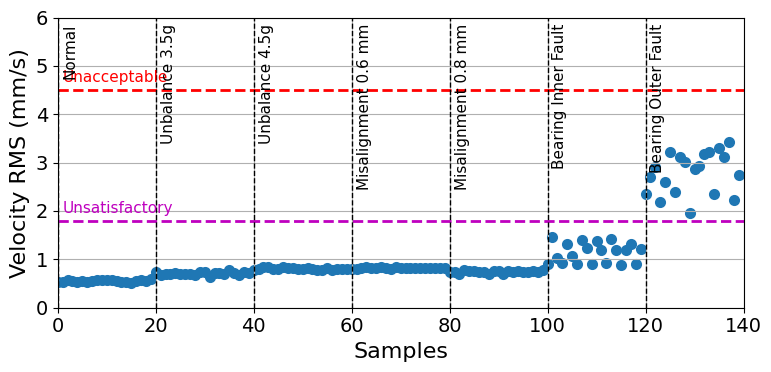

In [ ]:
import numpy as np
import scipy.signal
import matplotlib.pyplot as plt

file_in = '/content/drive/MyDrive/PHM SUNYK/Datasets/Raw_RK4.mat'
data = loadmat(file_in)

nor    = data['Nor']
unb35  = data['Unb35']
unb45  = data['Unb45']
mis06  = data['Mis06']
mis08  = data['Mis08']
binner = data['Bin']
bouter = data['Bout']

# Data setup: concatenate all datasets
raw = np.concatenate((
    nor.flatten(),
    unb35.flatten(),
    unb45.flatten(),
    mis06.flatten(),
    mis08.flatten(),
    binner.flatten(),
    bouter.flatten()
))

fs = 12800  # Sampling rate
N = len(raw)  # Number of samples
tt = np.arange(N) / fs

fac = 1000 * 9.81  # Scale factor for conversion to mm/s
frms = []

# RMS calculation
for j in range(1, N // fs + 1):
    i1 = int((j - 1) * fs)  # Start index of the segment
    i2 = int(j * fs)  # End index of the segment
    acc = raw[i1:i2]  # Extract segment data

    # Frequency-domain analysis
    f, pxx = scipy.signal.welch(
        acc, fs=fs, window='hann', nperseg=fs, noverlap=0, nfft=fs
    )  # Power spectrum
    vpsd = pxx[1:] / (2 * np.pi * f[1:])**2  # Velocity spectrum
    vpsd = vpsd * fac**2  # Unit conversion
    frms.append(np.sqrt(np.sum(vpsd[10:1000])))  # RMS calculation

frms = np.array(frms)  # Convert to array


# Segment boundaries and labels
xlines = [0, 20, 40, 60, 80, 100, 120]
labels = [
    'Normal',
    'Unbalance 3.5g',
    'Unbalance 4.5g',
    'Misalignment 0.6 mm',
    'Misalignment 0.8 mm',
    'Bearing Inner Fault',
    'Bearing Outer Fault'
]

# Visualization
plt.figure(figsize=(8, 4))
plt.scatter(np.arange(len(frms)), frms, linewidth=2)
plt.grid(True)
plt.axhline(y=1.8, color='m', linestyle='--', linewidth=2)
plt.text(1, 1.9, 'Unsatisfactory', color='m',
         verticalalignment='bottom', horizontalalignment='left', fontsize=11)
plt.axhline(y=4.5, color='r', linestyle='--', linewidth=2)
plt.text(1, 4.6, 'Unacceptable', color='r',
         verticalalignment='bottom', horizontalalignment='left', fontsize=11)

for xline, label in zip(xlines, labels):
    plt.axvline(x=xline, color='k', linestyle='--', linewidth=1)
    plt.text(xline + 1, plt.ylim()[1] * 1.25, label,
             rotation=90, verticalalignment='top', fontsize=11)

plt.xlim([0, len(frms)])
plt.ylim([0, 6])
plt.xlabel('Samples')
plt.ylabel('Velocity RMS (mm/s)')
plt.tight_layout()
plt.show()

## IMS Anomaly detection


### 1. Data and analysis settings

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.signal import hilbert, welch
from scipy.stats import f
from tqdm.auto import tqdm

# IMS data directory in Google Drive
base_path = '/content/drive/MyDrive/PHM SUNYK/Datasets/Bearing_IMS'

# Outer-race fault data
dataset_name = 'IMS_2nd_ch1'

# Use the following line for the inner-race fault data
# dataset_name = 'IMS_1st_ch5'

remove_last_cycles = 5
train_ratio = 0.30
alpha = 1e-6

# Search band for identifying the actual peak near each nominal frequency
frequency_search_half_width_hz = 10.0

# Search band for extracting the peak amplitude in each cycle
feature_search_half_width_hz = 10.0

# Fraction of late-life cycles used to identify the actual frequencies
# This post-test setting uses late-life signals with clearer fault components.
reference_life_ratio = 0.20

# Frequency range used to calculate ISO velocity RMS
iso_f_low_hz = 10.0
iso_f_high_hz = 1000.0

data_path = os.path.join(base_path, f'{dataset_name}.mat')
info_path = os.path.join(base_path, 'info.mat')

data = loadmat(data_path, variable_names=[dataset_name])
xall = np.asarray(data[dataset_name], dtype=float)

if remove_last_cycles > 0:
    xall = xall[:, :-remove_last_cycles]

info = loadmat(info_path)

fs = float(np.squeeze(info['fs']))
fr_nominal = float(np.squeeze(info['fr']))
D = float(np.squeeze(info['D']))
d_ball = float(np.squeeze(info['d']))
Nb = float(np.squeeze(info['Nb']))
alpha_contact = float(np.squeeze(info['alpha']))

n_samples, n_cycles = xall.shape
n_train = int(round(n_cycles * train_ratio))

print('Dataset            =', dataset_name)
print('Data shape         =', xall.shape)
print('Sampling frequency =', fs, 'Hz')
print('Training cycles    =', n_train)
print('Monitoring cycles  =', n_cycles - n_train)

Dataset            = IMS_2nd_ch1
Data shape         = (20480, 979)
Sampling frequency = 20480.0 Hz
Training cycles    = 294
Monitoring cycles  = 685


### 2. Nominal bearing fault frequencies

In [ ]:
def calc_bearing_fault_freq(D, d, Nb, alpha, fr):
    bpfo = Nb * fr / 2 * (1 - d / D * np.cos(alpha))
    bpfi = Nb * fr / 2 * (1 + d / D * np.cos(alpha))
    ftf = fr / 2 * (1 - d / D * np.cos(alpha))
    bsf = D / d * fr * (1 - (d / D) ** 2 * np.cos(alpha) ** 2)
    return np.array([bpfo, bpfi, ftf, bsf])


fault_freqs_nominal = calc_bearing_fault_freq(
    D, d_ball, Nb, alpha_contact, fr_nominal
)

bpfo_nominal = fault_freqs_nominal[0]
bpfi_nominal = fault_freqs_nominal[1]

print(f'Nominal shaft frequency = {fr_nominal:.4f} Hz')
print(f'Nominal BPFO            = {bpfo_nominal:.4f} Hz')
print(f'Nominal BPFI            = {bpfi_nominal:.4f} Hz')

Nominal shaft frequency = 33.3333 Hz
Nominal BPFO            = 236.4035 Hz
Nominal BPFI            = 296.9299 Hz


### 3. Actual shaft and bearing fault frequencies

The actual frequencies are determined once and then applied consistently to all cycles. The shaft frequency is identified from the average raw spectrum of the late-life cycles. BPFO and BPFI are identified from their corresponding peaks in the average envelope spectrum. Searching for a new frequency in every cycle is avoided because it may track nearby noise peaks instead of the same physical component.

Using late-life data to identify the fault frequencies is a post-test analysis. For fully online anomaly detection, the frequencies should be obtained from a tachometer and bearing geometry or established in a separate reference test before monitoring begins.

Averaging reference spectra:   0%|          | 0/196 [00:00<?, ?it/s]

Actual shaft frequency = 30.0000 Hz
Actual BPFO            = 236.0000 Hz
Actual BPFI            = 301.0000 Hz


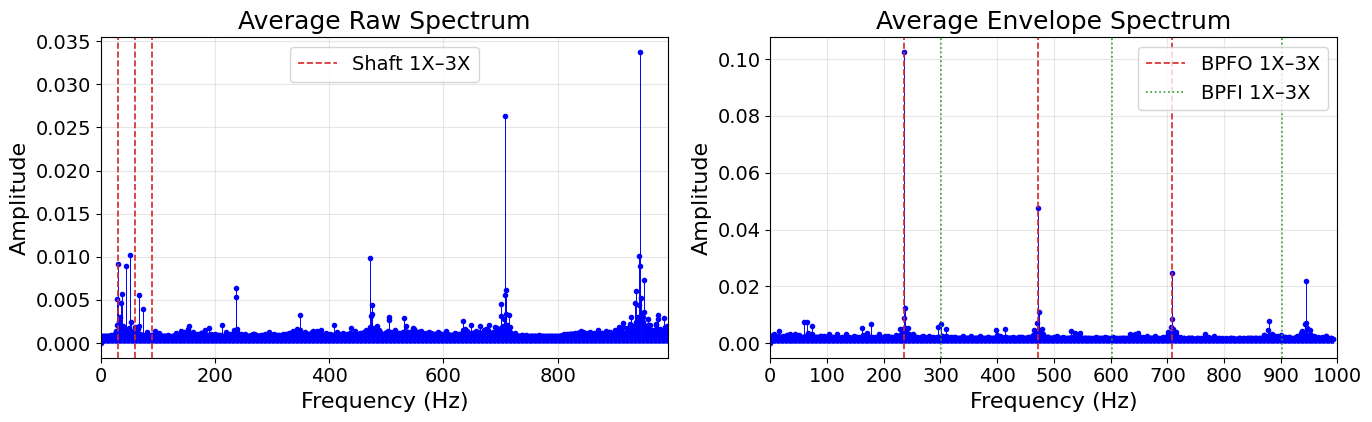

In [ ]:
# ============================================================
# Identify actual shaft/BPFO/BPFI frequencies from late-life
# reference cycles, using the shared single_sided_fft /
# envelope_spectrum / find_peak_near from the "Settings and
# Utilities" section at the top of the notebook.
# ============================================================
reference_start = int(np.floor(n_cycles * (1 - reference_life_ratio)))
reference_indices = np.arange(reference_start, n_cycles)

raw_mean_spectrum = None
env_mean_spectrum = None
for idx in tqdm(reference_indices, desc='Averaging reference spectra'):
    freq, raw_amp = single_sided_fft(xall[:, idx], fs)
    _, env_amp = envelope_spectrum(xall[:, idx], fs)
    if raw_mean_spectrum is None:
        raw_mean_spectrum = np.zeros_like(raw_amp)
        env_mean_spectrum = np.zeros_like(env_amp)
    raw_mean_spectrum += raw_amp
    env_mean_spectrum += env_amp

raw_mean_spectrum /= reference_indices.size
env_mean_spectrum /= reference_indices.size

_, fr_actual = find_peak_near(freq, raw_mean_spectrum, fr_nominal, frequency_search_half_width_hz)
_, bpfo_actual = find_peak_near(freq, env_mean_spectrum, bpfo_nominal, frequency_search_half_width_hz)
_, bpfi_actual = find_peak_near(freq, env_mean_spectrum, bpfi_nominal, frequency_search_half_width_hz)

print(f'Actual shaft frequency = {fr_actual:.4f} Hz')
print(f'Actual BPFO            = {bpfo_actual:.4f} Hz')
print(f'Actual BPFI            = {bpfi_actual:.4f} Hz')

fmax = min(3.3 * max(fr_actual, bpfo_actual, bpfi_actual), fs / 2)
plot_mask = freq <= fmax

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

markerline, stemlines, baseline = axes[0].stem(
    freq[plot_mask], raw_mean_spectrum[plot_mask],
    linefmt='b-', markerfmt='bo', basefmt=' '
)
plt.setp(markerline, markersize=3)
plt.setp(stemlines, linewidth=0.7)
for order in range(1, 4):
    axes[0].axvline(order * fr_actual, color='tab:red', linestyle='--', linewidth=1.2,
                     label='Shaft 1X–3X' if order == 1 else None)
axes[0].set_xlim(0, fmax)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Average Raw Spectrum')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

markerline, stemlines, baseline = axes[1].stem(
    freq[plot_mask], env_mean_spectrum[plot_mask],
    linefmt='b-', markerfmt='bo', basefmt=' '
)
plt.setp(markerline, markersize=3)
plt.setp(stemlines, linewidth=0.7)
for order in range(1, 4):
    axes[1].axvline(order * bpfo_actual, color='tab:red', linestyle='--', linewidth=1.2,
                     label='BPFO 1X–3X' if order == 1 else None)
    axes[1].axvline(order * bpfi_actual, color='tab:green', linestyle=':', linewidth=1.2,
                     label='BPFI 1X–3X' if order == 1 else None)
axes[1].set_xlim(0, fmax)
axes[1].set_xticks(np.arange(0, fmax + 100, 100))
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Amplitude')
axes[1].set_title('Average Envelope Spectrum')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


### 4. Extraction of nine features

In [ ]:
feature_names = (
    [f'Shaft_{order}X' for order in range(1, 4)]
    + [f'BPFO_{order}X' for order in range(1, 4)]
    + [f'BPFI_{order}X' for order in range(1, 4)]
)


def peak_amplitude_at_harmonics(freq, amplitude, fundamental, half_width):
    """Peak amplitude at 1X/2X/3X of a fundamental frequency.
    Input : freq, amplitude (spectrum), fundamental (Hz), half_width (search window)
    Output: list of 3 peak amplitudes
    """
    return [find_peak_near(freq, amplitude, order * fundamental, half_width)[0]
            for order in range(1, 4)]


features = np.zeros((n_cycles, 9))

for cycle_idx in tqdm(range(n_cycles), desc='Extracting nine features'):
    signal = xall[:, cycle_idx]
    freq, raw_amp = single_sided_fft(signal, fs)
    _, env_amp = envelope_spectrum(signal, fs)

    shaft_features = peak_amplitude_at_harmonics(freq, raw_amp, fr_actual, feature_search_half_width_hz)
    bpfo_features = peak_amplitude_at_harmonics(freq, env_amp, bpfo_actual, feature_search_half_width_hz)
    bpfi_features = peak_amplitude_at_harmonics(freq, env_amp, bpfi_actual, feature_search_half_width_hz)

    features[cycle_idx] = shaft_features + bpfo_features + bpfi_features

feature_table = pd.DataFrame(features, columns=feature_names)
feature_table.insert(0, 'Cycle', np.arange(1, n_cycles + 1))
feature_table.head()


Extracting nine features:   0%|          | 0/979 [00:00<?, ?it/s]

,Cycle,Shaft_1X,Shaft_2X,Shaft_3X,BPFO_1X,BPFO_2X,BPFO_3X,BPFI_1X,BPFI_2X,BPFI_3X
0,1,0.003365,0.011834,0.001703,0.002585,0.003808,0.002135,0.002580,0.002203,0.002425
1,2,0.003632,0.012307,0.001515,0.003810,0.002841,0.002656,0.002298,0.002544,0.002215
2,3,0.006215,0.011630,0.002083,0.002755,0.002925,0.001894,0.002078,0.002281,0.002172
3,4,0.006155,0.011518,0.002247,0.004585,0.002686,0.002285,0.002773,0.001720,0.003632
4,5,0.006318,0.010675,0.002029,0.004910,0.002261,0.002335,0.002846,0.002314,0.002186


### 5. Mahalanobis distance

In [ ]:
train_features = features[:n_train]

mean_train = np.mean(train_features, axis=0)
cov_train = np.cov(train_features, rowvar=False, ddof=1)

# Use the pseudoinverse for numerical stability with correlated features.
inv_cov_train = np.linalg.pinv(cov_train, rcond=1e-12)

diff = features - mean_train
md_squared = np.einsum('ij,jk,ik->i', diff, inv_cov_train, diff)

p = features.shape[1]
n = n_train

if n <= p:
    raise ValueError('The number of training cycles must be larger than the number of features.')

md_threshold = (
    p * (n + 1) * (n - 1) / (n * (n - p))
    * f.ppf(1 - alpha, p, n - p)
)

print('Number of features =', p)
print('Training cycles     =', n)
print(f'F-based threshold   = {md_threshold:.4f}')
print(f'Covariance rank     = {np.linalg.matrix_rank(cov_train)} / {p}')

Number of features = 9
Training cycles     = 294
F-based threshold   = 49.4125
Covariance rank     = 9 / 9


### 6. VRMS by ISO 10816

In [ ]:
def velocity_rms_from_acceleration_psd(
    acceleration_g, fs, f_low=10.0, f_high=1000.0
):
    acceleration_ms2 = np.asarray(acceleration_g, dtype=float) * 9.80665

    nperseg = min(int(round(fs)), acceleration_ms2.size)
    freq_psd, acceleration_psd = welch(
        acceleration_ms2,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=0,
        nfft=nperseg,
        detrend='constant',
        scaling='density'
    )

    valid = (
        (freq_psd >= f_low)
        & (freq_psd <= f_high)
        & (freq_psd > 0)
    )

    velocity_psd = acceleration_psd[valid] / (
        4 * np.pi**2 * freq_psd[valid]**2
    )

    velocity_rms_ms = np.sqrt(
        np.trapezoid(velocity_psd, freq_psd[valid])
    )
    return velocity_rms_ms * 1000


velocity_rms = np.array([
    velocity_rms_from_acceleration_psd(
        xall[:, idx], fs, iso_f_low_hz, iso_f_high_hz
    )
    for idx in tqdm(range(n_cycles), desc='Calculating velocity RMS')
])

print(f'Velocity RMS range = {velocity_rms.min():.4f}–{velocity_rms.max():.4f} mm/s')

Calculating velocity RMS:   0%|          | 0/979 [00:00<?, ?it/s]

Velocity RMS range = 0.4718–2.5915 mm/s


### 7. Compare MD-based & ISO 10816

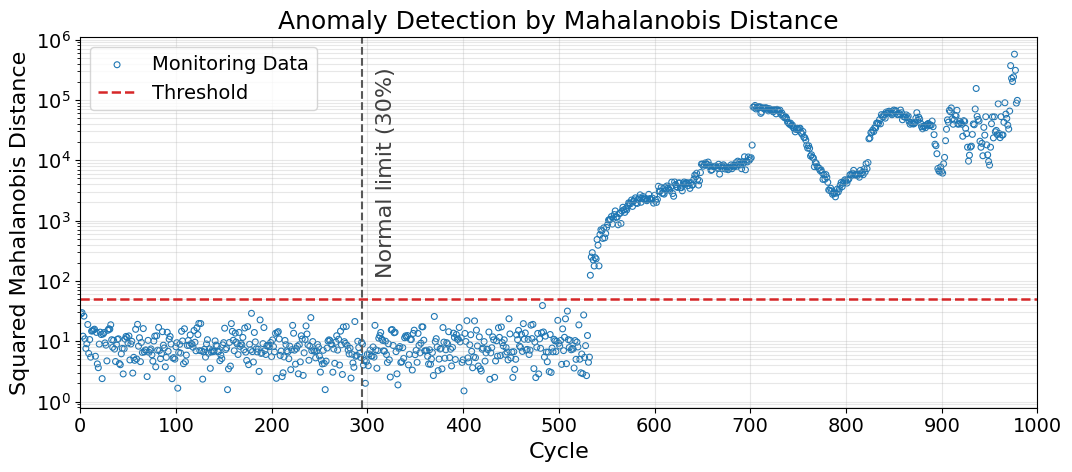

Anomaly start cycle = 533
Detection cycle after 5 consecutive exceedances = 537


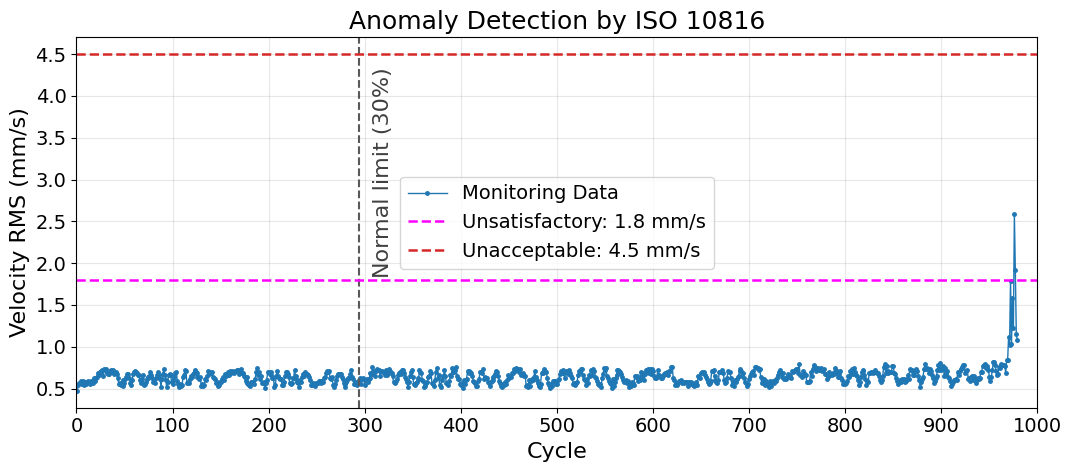

In [ ]:
cycles = np.arange(1, n_cycles + 1)
normal_limit = n_train

# Squared Mahalanobis distance
plt.figure(figsize=(11, 5))
plt.scatter(
    cycles,
    md_squared,
    s=18,
    facecolors='none',
    edgecolors='tab:blue',
    linewidths=0.8,
    label='Monitoring Data'
)
plt.axhline(
    md_threshold,
    color='tab:red',
    linestyle='--',
    linewidth=1.8,
    label='Threshold'
)
plt.axvline(
    normal_limit,
    color='0.35',
    linestyle='--',
    linewidth=1.5
)
plt.text(
    normal_limit + 0.015 * n_cycles,
    0.92,
    'Normal limit (30%)',
    transform=plt.gca().get_xaxis_transform(),
    rotation=90,
    va='top',
    ha='left',
    color='0.25'
)
plt.yscale('log')
plt.xlim(1, n_cycles)
plt.xticks(np.arange(0, n_cycles + 100, 100))
plt.xlabel('Cycle')
plt.ylabel('Squared Mahalanobis Distance')
plt.title('Anomaly Detection by Mahalanobis Distance')
plt.grid(True, which='both', alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

exceedance = md_squared[n_train:] > md_threshold
five_consecutive = np.convolve(exceedance.astype(int), np.ones(5, dtype=int), mode='valid')

detected = np.flatnonzero(five_consecutive == 5)

if detected.size > 0:
    anomaly_start_cycle = n_train + detected[0] + 1
    detection_cycle = anomaly_start_cycle + 4

    print('Anomaly start cycle =', anomaly_start_cycle)
    print('Detection cycle after 5 consecutive exceedances =', detection_cycle)
else:
    print('No anomaly was detected.')

# ISO 10816 velocity RMS
plt.figure(figsize=(11, 5))
plt.plot(
    cycles,
    velocity_rms,
    color='tab:blue',
    marker='o',
    markersize=2.5,
    linewidth=1,
    label='Monitoring Data'
)
plt.axvline(
    normal_limit,
    color='0.35',
    linestyle='--',
    linewidth=1.5
)
plt.text(
    normal_limit + 0.015 * n_cycles,
    0.92,
    'Normal limit (30%)',
    transform=plt.gca().get_xaxis_transform(),
    rotation=90,
    va='top',
    ha='left',
    color='0.25'
)
plt.axhline(
    1.8,
    color='magenta',
    linestyle='--',
    linewidth=1.8,
    label='Unsatisfactory: 1.8 mm/s'
)
plt.axhline(
    4.5,
    color='tab:red',
    linestyle='--',
    linewidth=1.8,
    label='Unacceptable: 4.5 mm/s'
)
plt.xlim(1, n_cycles)
plt.xticks(np.arange(0, n_cycles + 100, 100))
plt.xlabel('Cycle')
plt.ylabel('Velocity RMS (mm/s)')
plt.title('Anomaly Detection by ISO 10816')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

## Autoencoder

### read HS_ZeMA data

In [ ]:
# ============================================================
# Load pump/cooler/valve/accumulator condition labels
# ============================================================
import h5py
import numpy as np
import matplotlib.pyplot as plt

data_dir = '/content/drive/MyDrive/PHM SUNYK/Datasets/HS_ZeMA/'

with h5py.File(f'{data_dir}profile.mat', 'r') as f:
    profile = np.array(f['profile'])
if profile.shape[0] < profile.shape[1]:
    profile = profile.T
N_CYCLES = profile.shape[0]

# Target: Cooler condition (column 0). Normal = 100 (full efficiency).
cooler_normal = profile[:, 0] == 100
cooler_fault = profile[:, 0] != 100
print(f'Total cycles: {N_CYCLES}')
print(f'Cooler normal: {cooler_normal.sum()}, fault: {cooler_fault.sum()}')

# ============================================================
# Load and resample the 14 physical sensors to a common 5 Hz grid
# ============================================================
sensors_100hz = ['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'EPS1']
sensors_10hz = ['FS1', 'FS2']
sensors_1hz = ['TS1', 'TS2', 'TS3', 'TS4', 'VS1']

def load_sensor_mat(name):
    """Load a single ZeMA sensor .mat file (v7.3/HDF5 format).
    Input: sensor name (e.g. 'PS1')
    Output: 2D array (n_cycles, n_timesteps_native), oriented so axis 0 = cycles
    """
    with h5py.File(f'{data_dir}{name}.mat', 'r') as f:
        arr = np.array(f[name])
    if arr.shape[0] != N_CYCLES:
        arr = arr.T
    return arr

def resample_to_5hz(x_native, native_rate, target_len=300):
    """Resample one sensor's cycle data to a common 5 Hz / 300-sample grid.
    Input: x_native (n_cycles, n_timesteps_native), native_rate (Hz)
    Output: (n_cycles, target_len)
    """
    n_cycles, n_native = x_native.shape
    if native_rate > 5:
        factor = native_rate // 5
        trimmed = x_native[:, :factor * target_len]
        return trimmed.reshape(n_cycles, target_len, factor).mean(axis=2)
    elif native_rate < 5:
        x_old = np.linspace(0, 1, n_native)
        x_new = np.linspace(0, 1, target_len)
        return np.array([np.interp(x_new, x_old, row) for row in x_native])
    else:
        return x_native

sensor_list = (
    [(s, 100) for s in sensors_100hz]
    + [(s, 10) for s in sensors_10hz]
    + [(s, 1) for s in sensors_1hz]
)

channels = []
for name, rate in sensor_list:
    raw = load_sensor_mat(name)
    channels.append(resample_to_5hz(raw, rate))

X_all = np.stack(channels, axis=-1)  # (n_cycles, 300, 14)
t_5hz = np.linspace(0, 60, 300)
print('X_all shape:', X_all.shape)

Total cycles: 2205
Cooler normal: 741, fault: 1464
X_all shape: (2205, 300, 14)


### Plot some samples

Representative normal cycles: [np.int64(1542), np.int64(1684), np.int64(1773), np.int64(1832)]


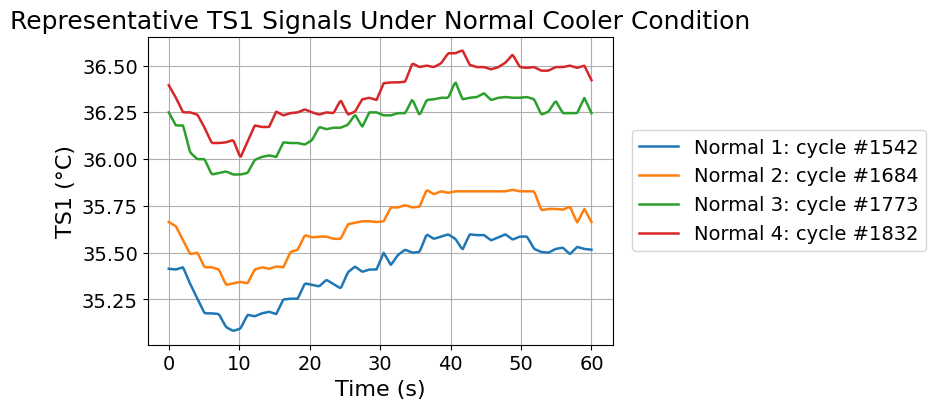

In [ ]:
# ============================================================
# Plot representative TS1 signals under normal cooler condition
# Four cycles are picked at different quantiles of the cycle
# mean, so the plot shows the natural spread within "normal"
# rather than just the two extremes.
# ============================================================
ts1_5hz = resample_to_5hz(load_sensor_mat('TS1'), 1)
cooler_col = profile[:, 0]
cooler_normal_indices = np.where(cooler_col == 100)[0]

ts1_cooler_normal = ts1_5hz[cooler_normal_indices]
normal_cycle_means = ts1_cooler_normal.mean(axis=1)

target_levels = np.quantile(normal_cycle_means, [0.05, 0.35, 0.65, 0.95])
display_normal_cycles = [
    cooler_normal_indices[np.argmin(np.abs(normal_cycle_means - level))]
    for level in target_levels
]
print('Representative normal cycles:', display_normal_cycles)

plt.figure(figsize=(6, 4))
for number, cycle_index in enumerate(display_normal_cycles, start=1):
    plt.plot(t_5hz, ts1_5hz[cycle_index], linewidth=1.8, label=f'Normal {number}: cycle #{cycle_index}')
plt.xlabel('Time (s)')
plt.ylabel('TS1 (°C)')
plt.title('Representative TS1 Signals Under Normal Cooler Condition')
plt.grid(True)
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.show()


### train using training set

Normal training: (444, 300, 14) | validation: (148, 300, 14) | test: (149, 300, 14)


Model: "compact_cnn_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 300, 14)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_conv1 (Conv1D)          │ (None, 150, 8)         │           792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout1 (Dropout)      │ (None, 150, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Conv1D)                 │ (None, 75, 16)         │           912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_deconv1                 │ (None, 150, 8)         │         1,032 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout1 (Dropout)      │ (None, 150, 8)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Conv1DTranspose)        │ (None, 300, 14)        │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,646 (14.24 KB)

 Trainable params: 3,646 (14.24 KB)

 Non-trainable params: 0 (0.00 B)

Total trainable parameters: 3,646
Training stopped at epoch: 115
Best epoch: 100, best validation loss: 0.058602


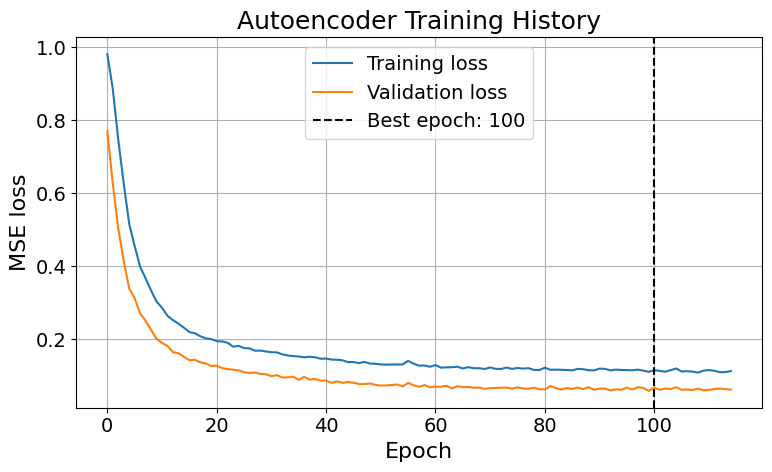

In [ ]:
# ============================================================
# Split cooler-normal cycles into training, validation, and test sets
# ============================================================
X_normal = X_all[cooler_normal]
n_normal = X_normal.shape[0]

rng = np.random.default_rng(42)
indices = rng.permutation(n_normal)
n_train = int(0.60 * n_normal)
n_val = int(0.20 * n_normal)

X_train = X_normal[indices[:n_train]]
X_val = X_normal[indices[n_train:n_train + n_val]]
X_test_normal = X_normal[indices[n_train + n_val:]]
print('Normal training:', X_train.shape, '| validation:', X_val.shape, '| test:', X_test_normal.shape)

# Normalize all data using statistics from the normal training set only
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)
std = np.where(std == 0, 1.0, std)

X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std
X_test_normal_norm = (X_test_normal - mean) / std

# ============================================================
# Build a compact two-stage 1D-CNN autoencoder
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

seq_len = X_train_norm.shape[1]
n_channels = X_train_norm.shape[2]

inputs = layers.Input(shape=(seq_len, n_channels), name='input')
x = layers.Conv1D(8, kernel_size=7, strides=2, padding='same', activation='relu', name='encoder_conv1')(inputs)
x = layers.Dropout(0.2, name='encoder_dropout1')(x)
x = layers.Conv1D(16, kernel_size=7, strides=2, padding='same', activation='relu', name='latent')(x)

x = layers.Conv1DTranspose(8, kernel_size=8, strides=2, padding='same', activation='relu', name='decoder_deconv1')(x)
x = layers.Dropout(0.2, name='decoder_dropout1')(x)
outputs = layers.Conv1DTranspose(n_channels, kernel_size=8, strides=2, padding='same', activation='linear', name='output')(x)

model = models.Model(inputs, outputs, name='compact_cnn_autoencoder')
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')
model.summary()
print(f'Total trainable parameters: {model.count_params():,}')

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
history = model.fit(
    X_train_norm, X_train_norm,
    validation_data=(X_val_norm, X_val_norm),
    epochs=120, batch_size=32,
    callbacks=[early_stop], verbose=0
)

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
print(f'Training stopped at epoch: {len(history.history["loss"])}')
print(f'Best epoch: {best_epoch}, best validation loss: {min(history.history["val_loss"]):.6f}')

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.axvline(best_epoch, color='k', linestyle='--', label=f'Best epoch: {best_epoch}')
plt.xlabel('Epoch'); plt.ylabel('MSE loss')
plt.title('Autoencoder Training History')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


### apply to validation set

Validation cycles: 148
Anomaly threshold at 95th percentile: 0.2765


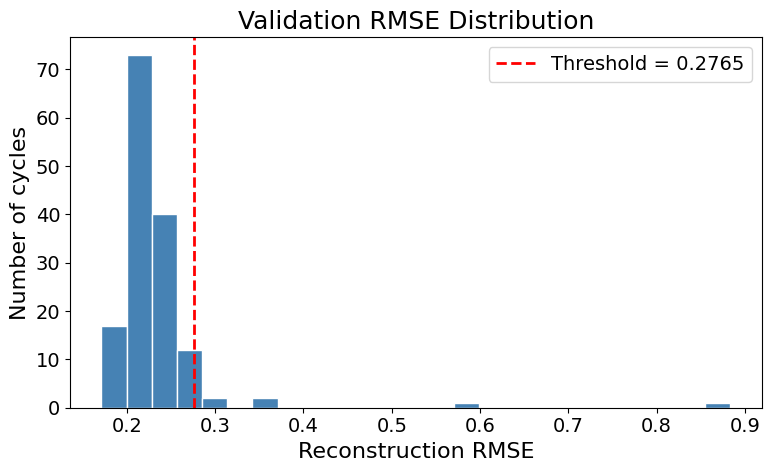

In [ ]:
# ============================================================
# Determine the anomaly threshold from normal validation cycles
# ============================================================
def reconstruction_rmse(model, X):
    """Return one reconstruction RMSE value for each cycle.
    Input: trained model, X (n_samples, seq_len, n_channels)
    Output: 1D array of RMSE values, one per sample
    """
    X_pred = model.predict(X, verbose=0)
    return np.sqrt(np.mean((X - X_pred) ** 2, axis=(1, 2)))

val_rmse = reconstruction_rmse(model, X_val_norm)
threshold_percentile = 95
threshold = np.percentile(val_rmse, threshold_percentile)
print(f'Validation cycles: {len(val_rmse)}')
print(f'Anomaly threshold at {threshold_percentile}th percentile: {threshold:.4f}')

plt.figure(figsize=(8, 5))
plt.hist(val_rmse, bins=25, color='steelblue', edgecolor='white')
plt.axvline(threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
plt.xlabel('Reconstruction RMSE'); plt.ylabel('Number of cycles')
plt.title('Validation RMSE Distribution')
plt.legend(); plt.tight_layout(); plt.show()


### apply to new samples

Normal test cycles: 149, reduced-efficiency test cycles: 732
TN=137, FP=12, FN=0, TP=732
Normal detection rate: 0.919, false-alarm rate: 0.081
Fault detection rate: 1.000, missed-detection rate: 0.000
Balanced accuracy: 0.960


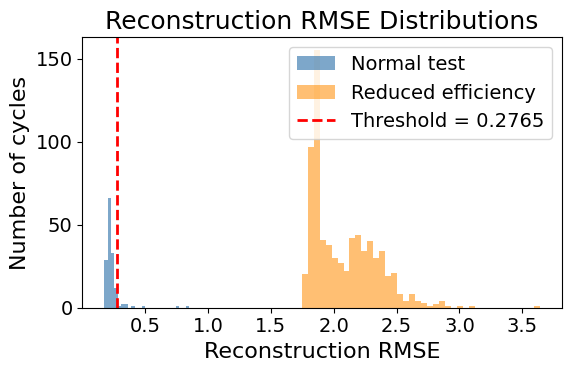

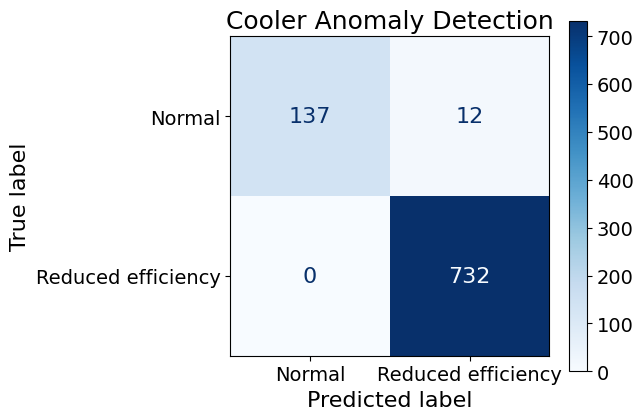

Displayed normal cycle: #1542, reduced-efficiency cycle: #1456


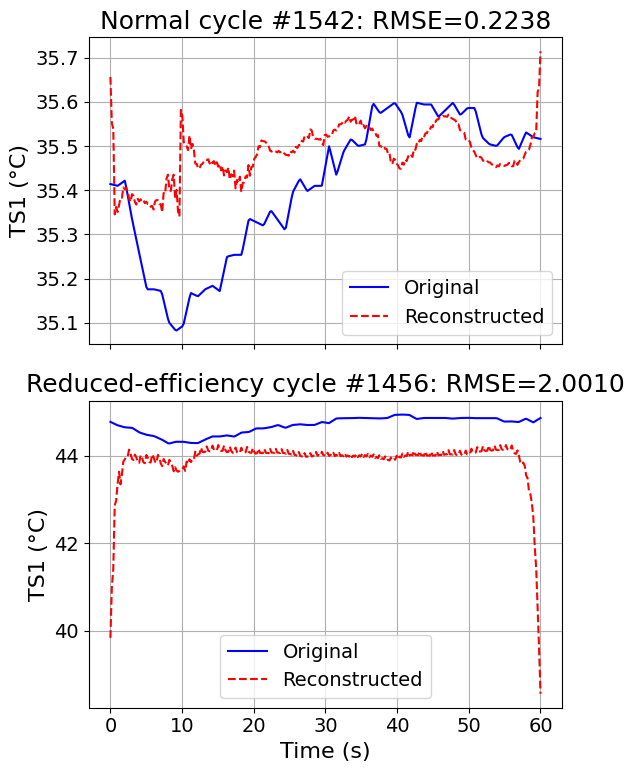

In [ ]:
# ============================================================
# Evaluate unseen normal cycles and reduced-efficiency cycles
# Cooler = 20 represents reduced efficiency; Cooler = 3 (near
# failure) is excluded from this practice.
# ============================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, balanced_accuracy_score

cooler_reduced = profile[:, 0] == 20
fault_cycle_ids = np.where(cooler_reduced)[0]

X_test_fault = X_all[cooler_reduced]
X_test_fault_norm = (X_test_fault - mean) / std

X_test = np.concatenate([X_test_normal_norm, X_test_fault_norm], axis=0)
y_true = np.concatenate([
    np.zeros(len(X_test_normal_norm), dtype=int),
    np.ones(len(X_test_fault_norm), dtype=int)
])

test_rmse = reconstruction_rmse(model, X_test)
y_pred = (test_rmse > threshold).astype(int)
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

specificity = tn / (tn + fp)
fault_detection_rate = tp / (tp + fn)
false_alarm_rate = fp / (tn + fp)
missed_detection_rate = fn / (tp + fn)
balanced_accuracy = balanced_accuracy_score(y_true, y_pred)

print(f'Normal test cycles: {len(X_test_normal_norm)}, reduced-efficiency test cycles: {len(X_test_fault_norm)}')
print(f'TN={tn}, FP={fp}, FN={fn}, TP={tp}')
print(f'Normal detection rate: {specificity:.3f}, false-alarm rate: {false_alarm_rate:.3f}')
print(f'Fault detection rate: {fault_detection_rate:.3f}, missed-detection rate: {missed_detection_rate:.3f}')
print(f'Balanced accuracy: {balanced_accuracy:.3f}')

# ============================================================
# Reconstruction-error distributions
# ============================================================
normal_test_rmse = test_rmse[y_true == 0]
fault_test_rmse = test_rmse[y_true == 1]

plt.figure(figsize=(6, 4))
plt.hist(normal_test_rmse, bins=25, alpha=0.70, label='Normal test', color='steelblue')
plt.hist(fault_test_rmse, bins=40, alpha=0.55, label='Reduced efficiency', color='darkorange')
plt.axvline(threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold = {threshold:.4f}')
plt.xlabel('Reconstruction RMSE'); plt.ylabel('Number of cycles')
plt.title('Reconstruction RMSE Distributions')
plt.legend(); plt.tight_layout(); plt.show()

# ============================================================
# Confusion matrix
# ============================================================
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Reduced efficiency'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Cooler Anomaly Detection')
plt.tight_layout(); plt.show()

# ============================================================
# Compare original vs. reconstructed TS1 signal for one
# representative normal cycle (median RMSE among the four
# cycles shown earlier) and one representative reduced-
# efficiency cycle (median RMSE among all fault test cycles)
# ============================================================
X_display_normal = X_all[display_normal_cycles]
X_display_normal_norm = (X_display_normal - mean) / std
X_display_normal_pred = model.predict(X_display_normal_norm, verbose=0)
display_normal_rmse = reconstruction_rmse(model, X_display_normal_norm)

normal_display_position = np.argmin(np.abs(display_normal_rmse - np.median(display_normal_rmse)))
normal_cycle_id = display_normal_cycles[normal_display_position]

fault_local_position = np.argmin(np.abs(fault_test_rmse - np.median(fault_test_rmse)))
fault_cycle_id = fault_cycle_ids[fault_local_position]
fault_test_position = len(X_test_normal_norm) + fault_local_position

ts1_channel = sensor_list.index(('TS1', 1))
X_test_pred = model.predict(X_test, verbose=0)

def denorm(x, ch):
    """Undo channel-wise normalization for plotting in original units."""
    return x[..., ch] * std[0, 0, ch] + mean[0, 0, ch]

normal_original = denorm(X_display_normal_norm[normal_display_position], ts1_channel)
normal_reconstructed = denorm(X_display_normal_pred[normal_display_position], ts1_channel)
fault_original = denorm(X_test[fault_test_position], ts1_channel)
fault_reconstructed = denorm(X_test_pred[fault_test_position], ts1_channel)

normal_rmse_value = display_normal_rmse[normal_display_position]
fault_rmse_value = fault_test_rmse[fault_local_position]
print(f'Displayed normal cycle: #{normal_cycle_id}, reduced-efficiency cycle: #{fault_cycle_id}')

fig, axes = plt.subplots(2, 1, figsize=(6, 8), sharex=True)

axes[0].plot(t_5hz, normal_original, color='b', label='Original')
axes[0].plot(t_5hz, normal_reconstructed, color='r', linestyle='--', label='Reconstructed')
axes[0].set_ylabel('TS1 (°C)')
axes[0].set_title(f'Normal cycle #{normal_cycle_id}: RMSE={normal_rmse_value:.4f}')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(t_5hz, fault_original, color='b', label='Original')
axes[1].plot(t_5hz, fault_reconstructed, color='r', linestyle='--', label='Reconstructed')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel('TS1 (°C)')
axes[1].set_title(f'Reduced-efficiency cycle #{fault_cycle_id}: RMSE={fault_rmse_value:.4f}')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()
